In [1]:
import uproot as ur
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [15]:
# Tools to load the ROOT file and access the tree. Define numpy arrays.

batches = [str(i) for i in range(1, 8)]
hvs = [str(f'{i}V_{j}mV') for i,j in zip([1000,1050,1100,1150],[20,20,40,40])]
channels = [1,8,11,12,15,16,17]

period = 100000 # Flash period in ns

def get_data_set(bn):

    data_set = {}
    for hvn in range(len(hvs)):
        data_set[hvn] = {}

        filename = f'Batch{batches[bn]}_{hvs[hvn]}_att625'
        file_path = f'I:/fd2_data/20260522/{filename}.root'
        data_file = ur.open(file_path)
        # print([key for key in list(data_file['pmt_events'].keys())])

        # Create numpy arrays for each branch of interest

        for channel in channels:
            channel_values = data_file['pmt_events']['channel'].array(library='np').flatten()
            channel_mask = (channel_values == channel)
            adc_values = data_file['pmt_events']['adc'].array(library='np').flatten()[channel_mask]
            pmt_time_values = data_file['pmt_events']['pmt_time'].array(library='np').flatten()[channel_mask]
            time_coarse_values = data_file['pmt_events']['time_coarse'].array(library='np').flatten()[channel_mask]
            time_fine_values = data_file['pmt_events']['time_fine'].array(library='np').flatten()[channel_mask]
            tdc_coarse_values = data_file['pmt_events']['tdc_coarse'].array(library='np').flatten()[channel_mask]
            tdc_start_values = data_file['pmt_events']['tdc_start'].array(library='np').flatten()[channel_mask]
            tdc_stop_values = data_file['pmt_events']['tdc_stop'].array(library='np').flatten()[channel_mask]
            tot_values = tdc_coarse_values*4. + tdc_stop_values*4/15. - tdc_start_values*4/15. # in ns. Note change in LSB to 4/15 ns.

            clock_period = period / 4  # in units of 4 ns clock ticks that defines the fine time
            pmt_time_modulus = pmt_time_values % clock_period
            # find the unique values and their counts
            unique, counts = np.unique(pmt_time_modulus, return_counts=True)
            # choose the modulus with the most events
            if len(counts) > 0:
                selected_pmt_time_modulus = unique[np.argmax(counts)]
                pmt_time_modulus_zeroeds = pmt_time_values % clock_period - selected_pmt_time_modulus # in 4ns bins
                signal_times = pmt_time_modulus_zeroeds * 4 + tdc_start_values*4./15.  # in ns  Note change in LSB
            else:
                selected_pmt_time_modulus = 0
                pmt_time_modulus_zeroeds = []
                signal_times = []

            data = {
                'channel': channel,
                'adcs': adc_values,
                'pmt_times': pmt_time_values,
                'time_coarses': time_coarse_values,
                'time_fines': time_fine_values,
                'tdc_coarses': tdc_coarse_values,
                'tdc_starts': tdc_start_values,
                'tdc_stops': tdc_stop_values,
                'tots': tot_values,
                'selected_pmt_time_modulus': selected_pmt_time_modulus,
                'pmt_time_modulus_zeroeds': pmt_time_modulus_zeroeds,
                'signal_times': signal_times
            }
            data_set[hvn][channel] = data

    return data_set

In [3]:
# Check properties of the data arrays

bn = 0
data_set = get_data_set(bn)


for hvn in range(len(hvs)):
    print(hvs[hvn])
    good_chan_count = {}
    for channel in data_set[hvn]:
        data = data_set[hvn][channel]

        adcs = data['adcs']
        if 10 < np.mean(adcs) < 1000:
            good_chan_count[channel] = len(adcs)
    print(good_chan_count)

    # Confirm meaning of the time data:
    # time_coarse: 16 bit unsigned int, counts of 2^28 * 4 ns clock -> LSB = 1.07 s
    # time_fine: 32 bit unsigned int, counts of 4 ns clock -> LSB = 4 ns (only lower 28 bits used)
    # pmt_time: 32 bit unsigned int, time_coarse * 2^28 + time_fine, counts of 4 ns clock -> LSB = 4 ns
    # tdc_start: 4 bit unsigned int, counts of 0.25 ns clock -> LSB = 0.25 ns

    #check_pmt_times = np.uint64(data['time_coarses']) * (2**28) + data['time_fines']
    # Check that pmt_time matches calculated value
    #if np.array_equal(data['pmt_times'], check_pmt_times):
        #print("pmt_time matches calculated value from time_coarse and time_fine")
    #else:
        #print("pmt_time does NOT match calculated value from time_coarse and time_fine")

1000V_20mV
{1: 47069, 8: 24455, 11: 125994, 12: 37066, 15: 32918, 16: 51023, 17: 39971}
1050V_20mV
{1: 47048, 8: 32033, 11: 125513, 12: 40422, 15: 33866, 16: 51909, 17: 40166}
1100V_40mV
{1: 48881, 8: 84704, 11: 96888, 12: 69217, 15: 41191, 16: 124932, 17: 58801}
1150V_40mV
{1: 50166, 8: 86110, 11: 99416, 12: 68986, 15: 42701, 16: 121033, 17: 60192}


In [4]:
channel = 1
hvn = 1
run_name = f'Batch{batches[bn]}_{hvs[hvn]}'
data = data_set[hvn][channel]

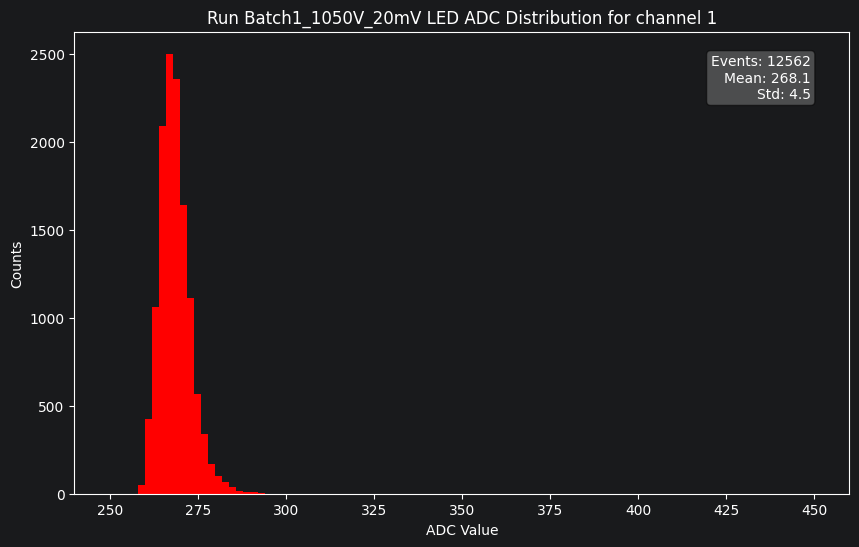

In [6]:
# fill histogram
plt.figure(figsize=(10, 6))

mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
plt.hist(data['adcs'][mask_led], bins=100, range=(250, 450), color='red')
# show number of events, mean and standard deviation, for values between 250 and 450
mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs'] >= 250) & (data['adcs'] <= 450))
# show number of events, mean and standard deviation for values between 250 and 450 in a box in upper right of plot
n_evt = np.sum(mask_adc)
mean = np.mean(data['adcs'][mask_adc])
std = np.std(data['adcs'][mask_adc])
textstr = '\n'.join((
    f'Events: {n_evt}',
    f'Mean: {mean:.1f}',
    f'Std: {std:.1f}'))
props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

# overlay a vertical line for the threshold
#plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
#plt.legend()
#plt.yscale('log')
plt.xlabel('ADC Value')
plt.ylabel('Counts')
plt.title(f'Run {run_name} LED ADC Distribution for channel {data['channel']}')
plt.savefig(f'I:/fd2_analyses/202605/adc_distribution_run{run_name}_chan{data['channel']:02d}.png')
plt.show()

Time Range: 0 to 15.20


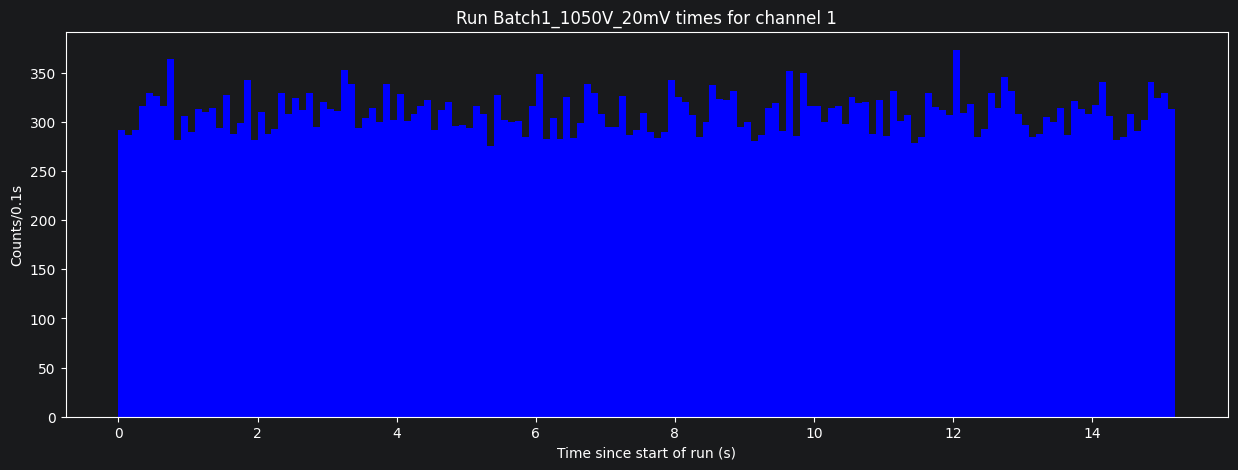

In [7]:
# plot the pmt time distribution with respect to the first signal - previously this was not uniform

time_min = np.min(data['pmt_times'])*4E-9
time_max = min(time_min+20,np.max(data['pmt_times'])*4E-9)
print(f"Time Range: 0 to {time_max-time_min:0.2f}")

# make the plot wider
plt.figure(figsize=(15, 5))
plt.hist(data['pmt_times']*4E-9-time_min, bins=np.arange(0.,time_max-time_min,0.1), color='blue')
#plt.hist(data['pmt_times']*4E-9-time_min, bins=np.arange(3.0,3.1,0.001), color='blue')
#plt.yscale('log')
plt.xlabel('Time since start of run (s)')
plt.ylabel('Counts/0.1s')
plt.title(f'Run {run_name} times for channel {channel}')
#plt.grid(True)
plt.savefig(f'I:/fd2_analyses/202605/time_distribution_run{run_name}_chan{channel:02d}.png')
plt.show()

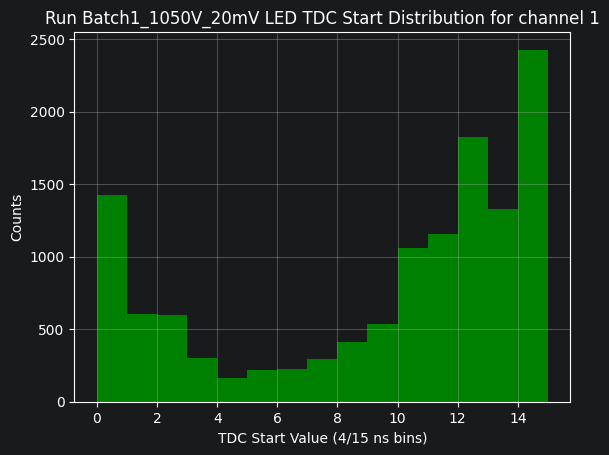

In [8]:
# look at distribution for LED pulses

mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)

plt.hist(data['tdc_starts'][mask_led], bins=np.arange(0,16,1), color='green')
plt.xlabel('TDC Start Value (4/15 ns bins)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} LED TDC Start Distribution for channel {channel}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/202605/tdc_start_distribution_run{run_name}_chan{channel:02d}LED.png')
plt.show()

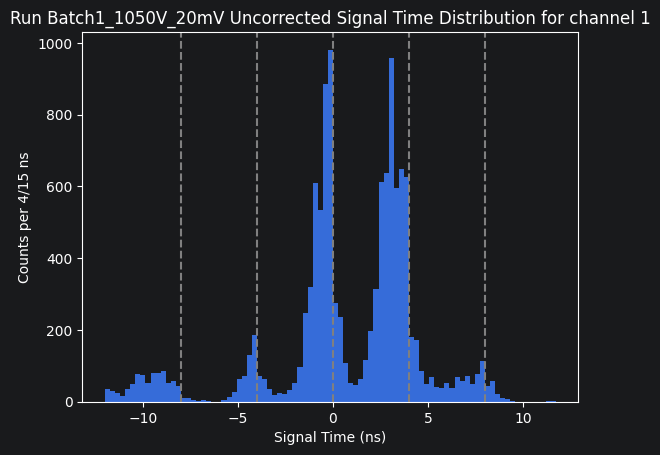

In [9]:
# Look at the signal times for the events near the expected LED flash time
mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
plt.hist(data['signal_times'][mask_led],bins=np.arange(-12.,12.,4./15))
plt.xlabel('Signal Time (ns)')
plt.ylabel('Counts per 4/15 ns')
plt.title(f'Run {run_name} Uncorrected Signal Time Distribution for channel {channel}')
# add some gray vertical lines:
for xval in [-8,-4,0,4,8]:
    plt.axvline(xval, color='gray', linestyle='dashed')
plt.savefig(f'I:/fd2_analyses/202605/signal_time_distribution_run{run_name}_chan{channel:02d}LED.png')
plt.show()

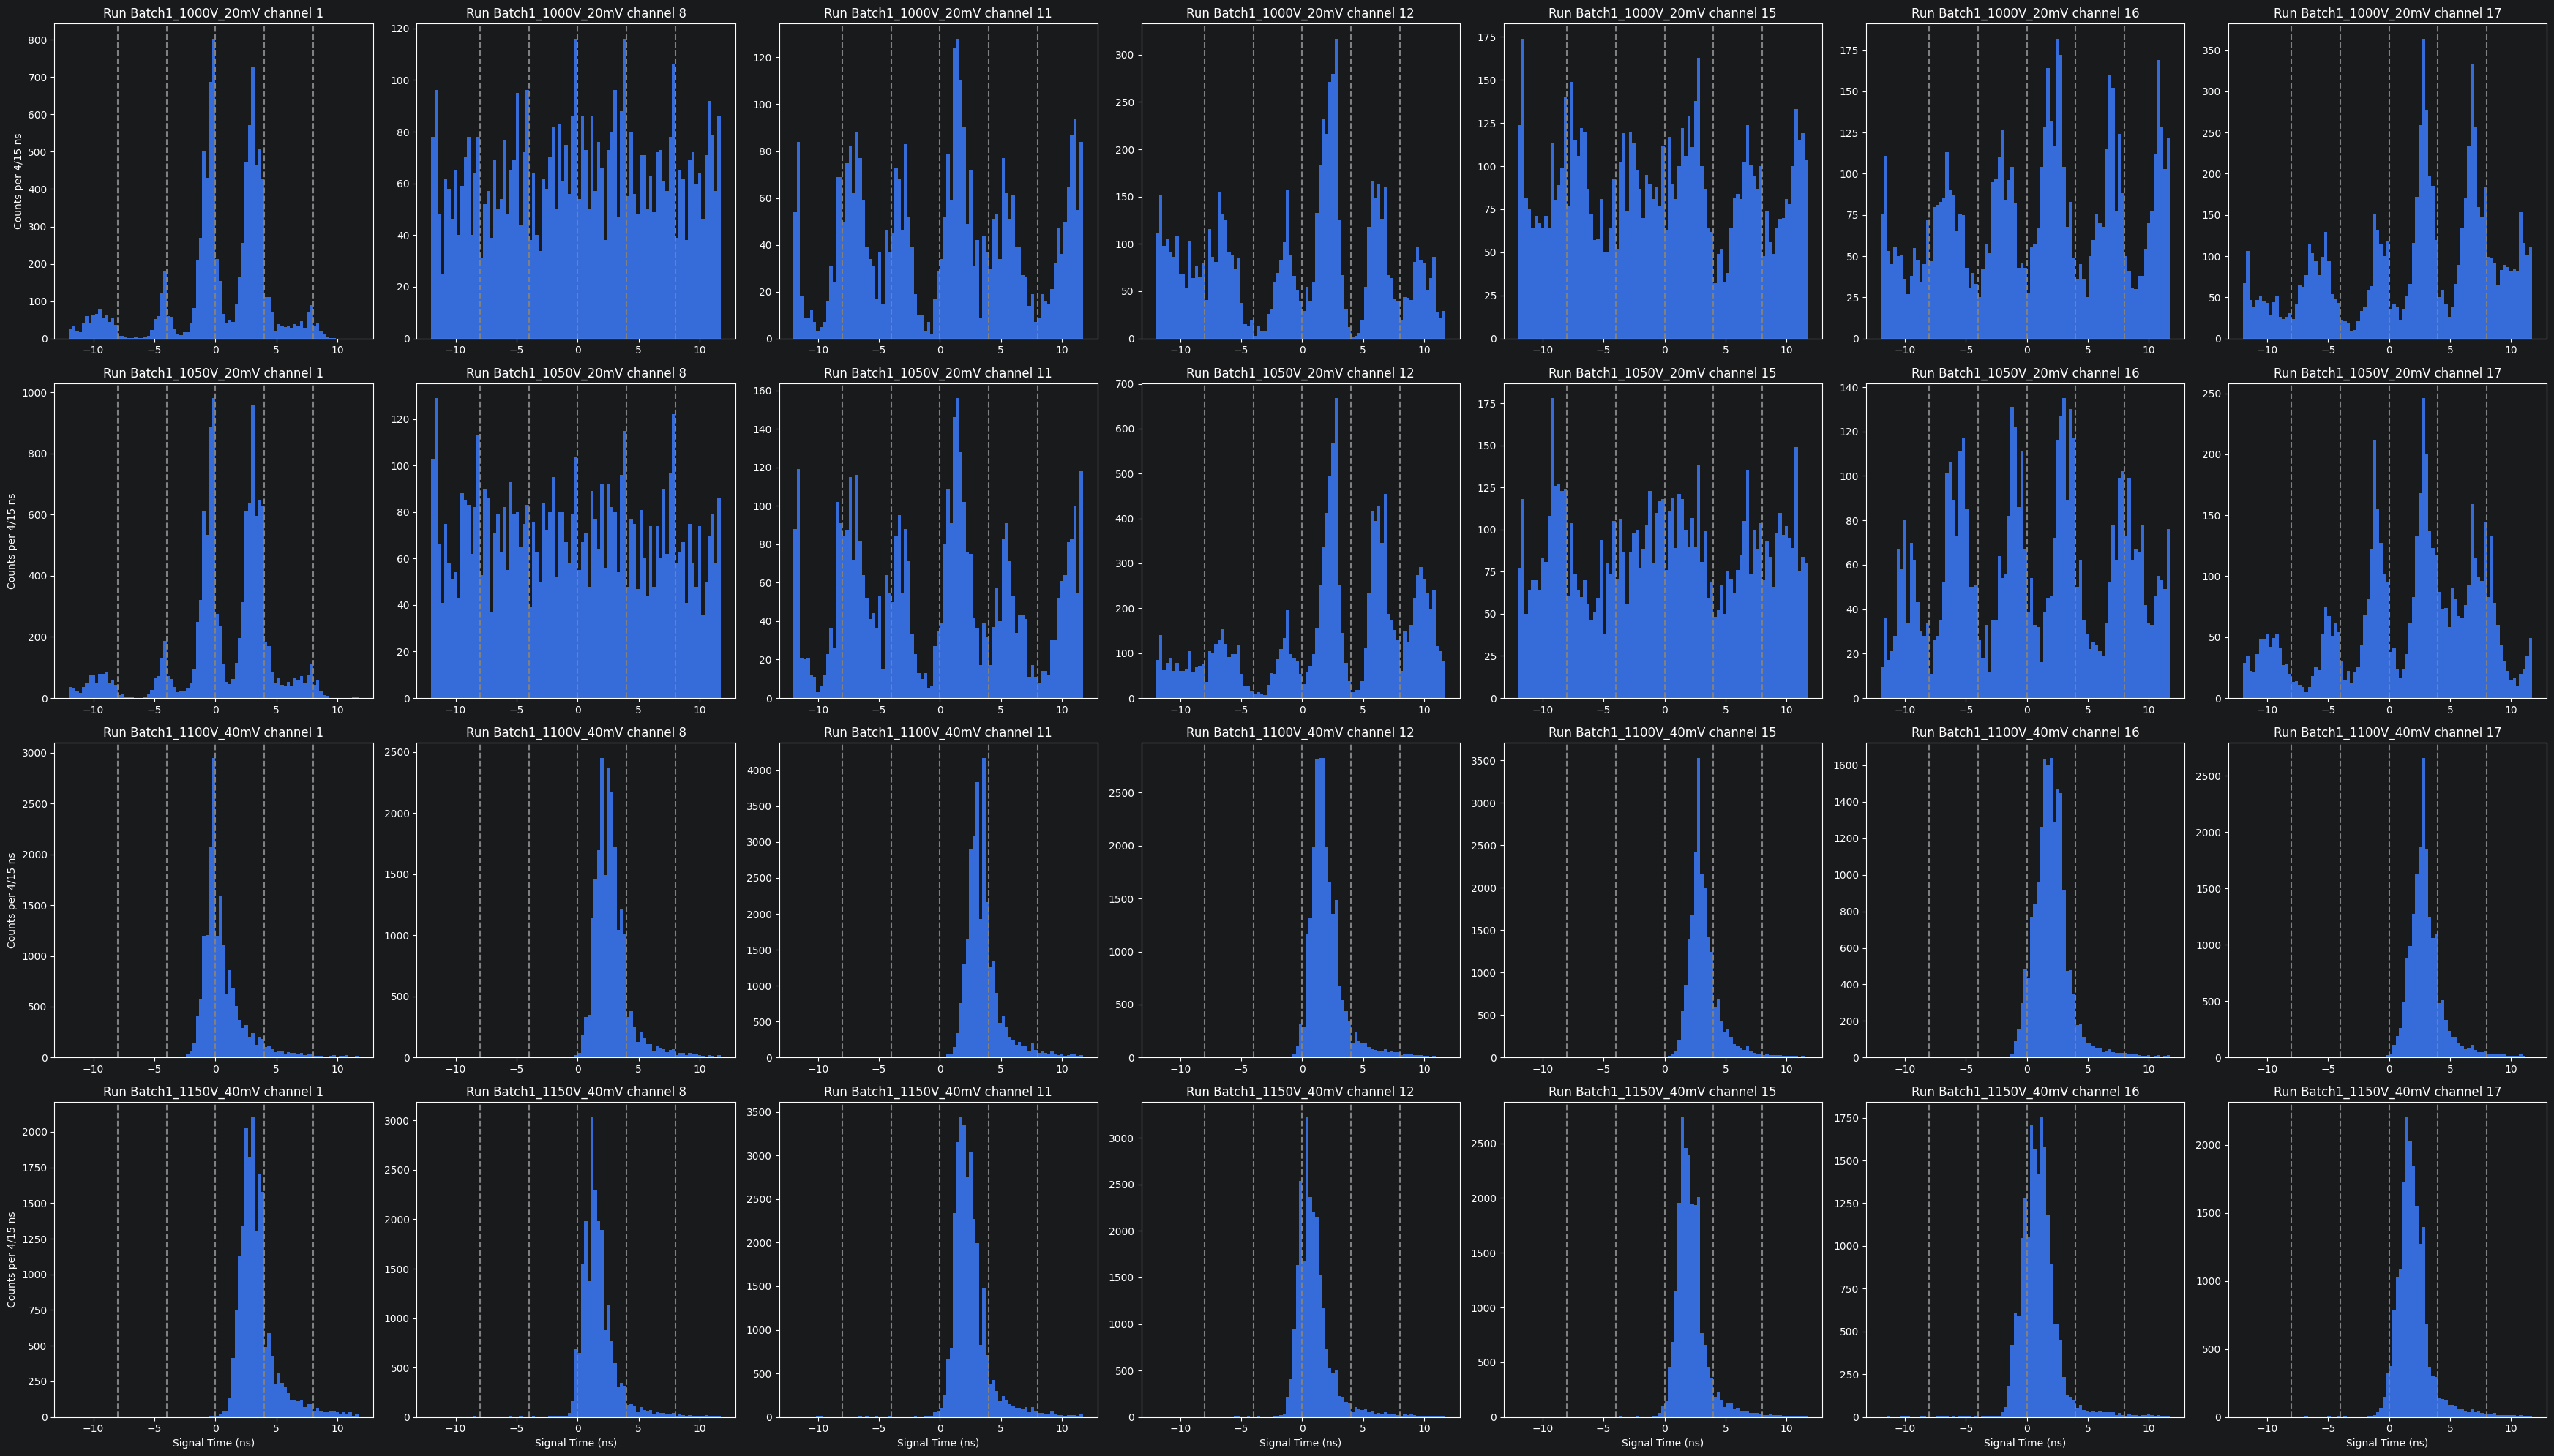

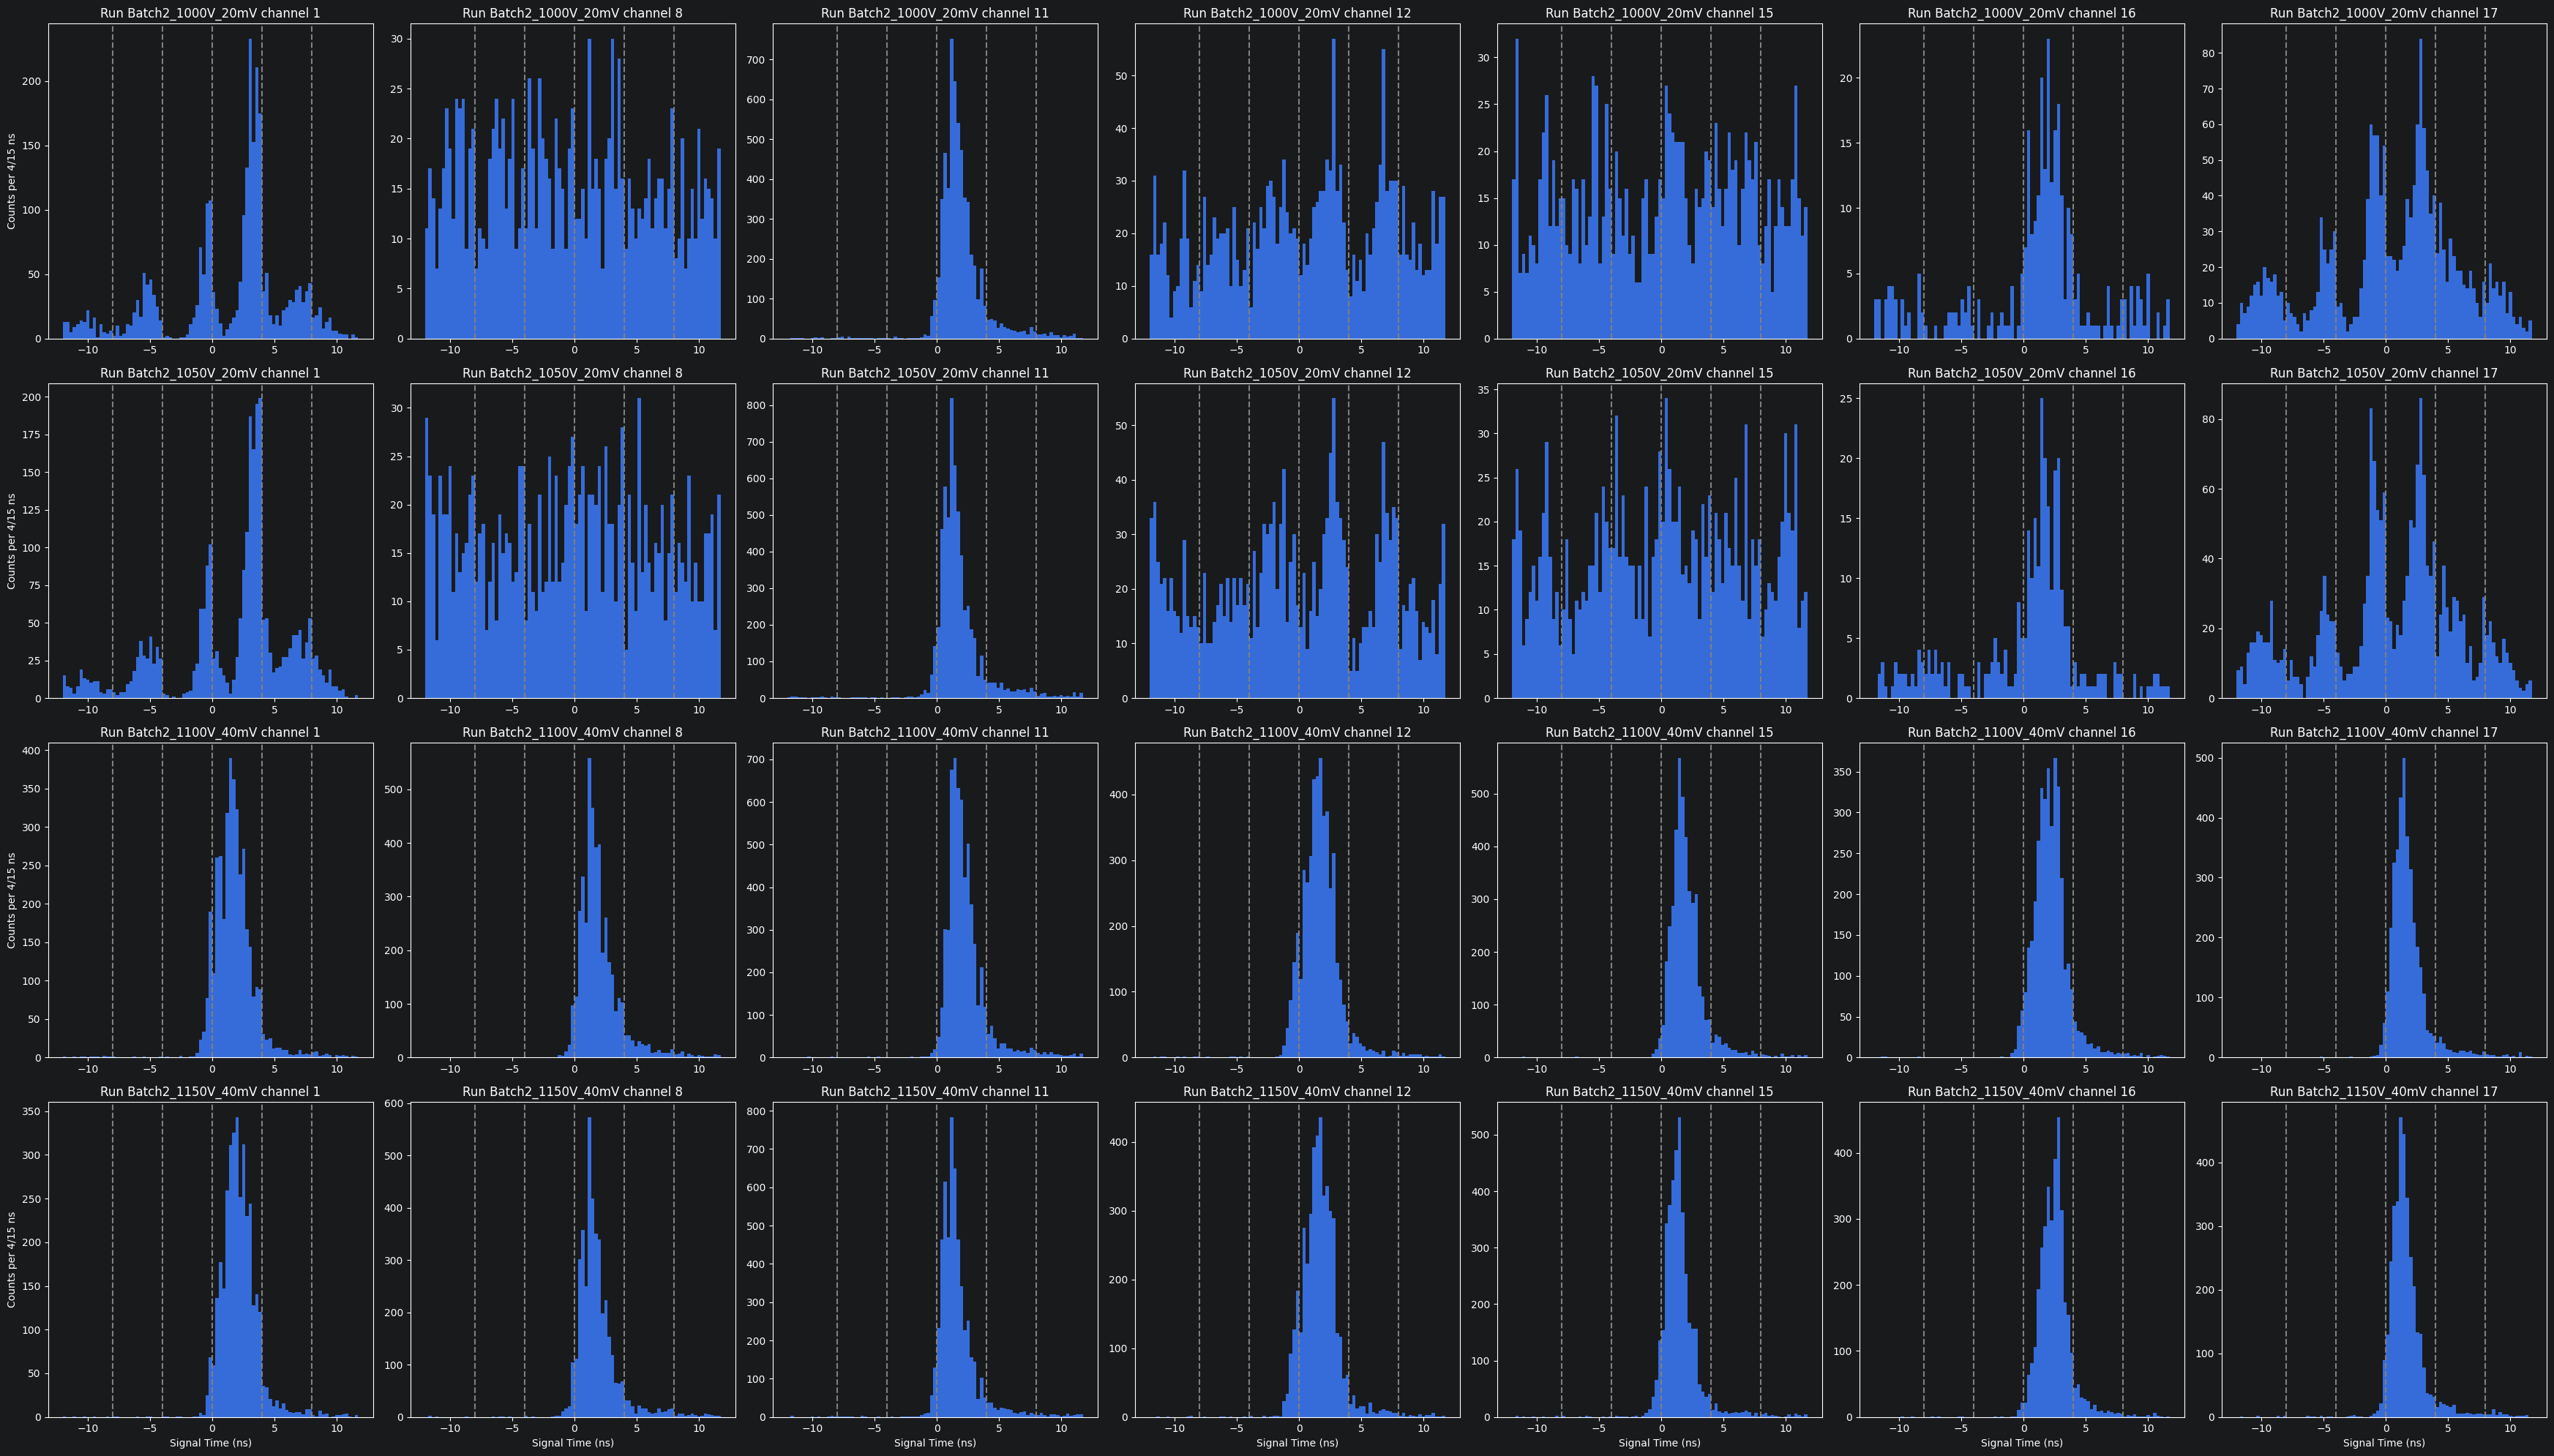

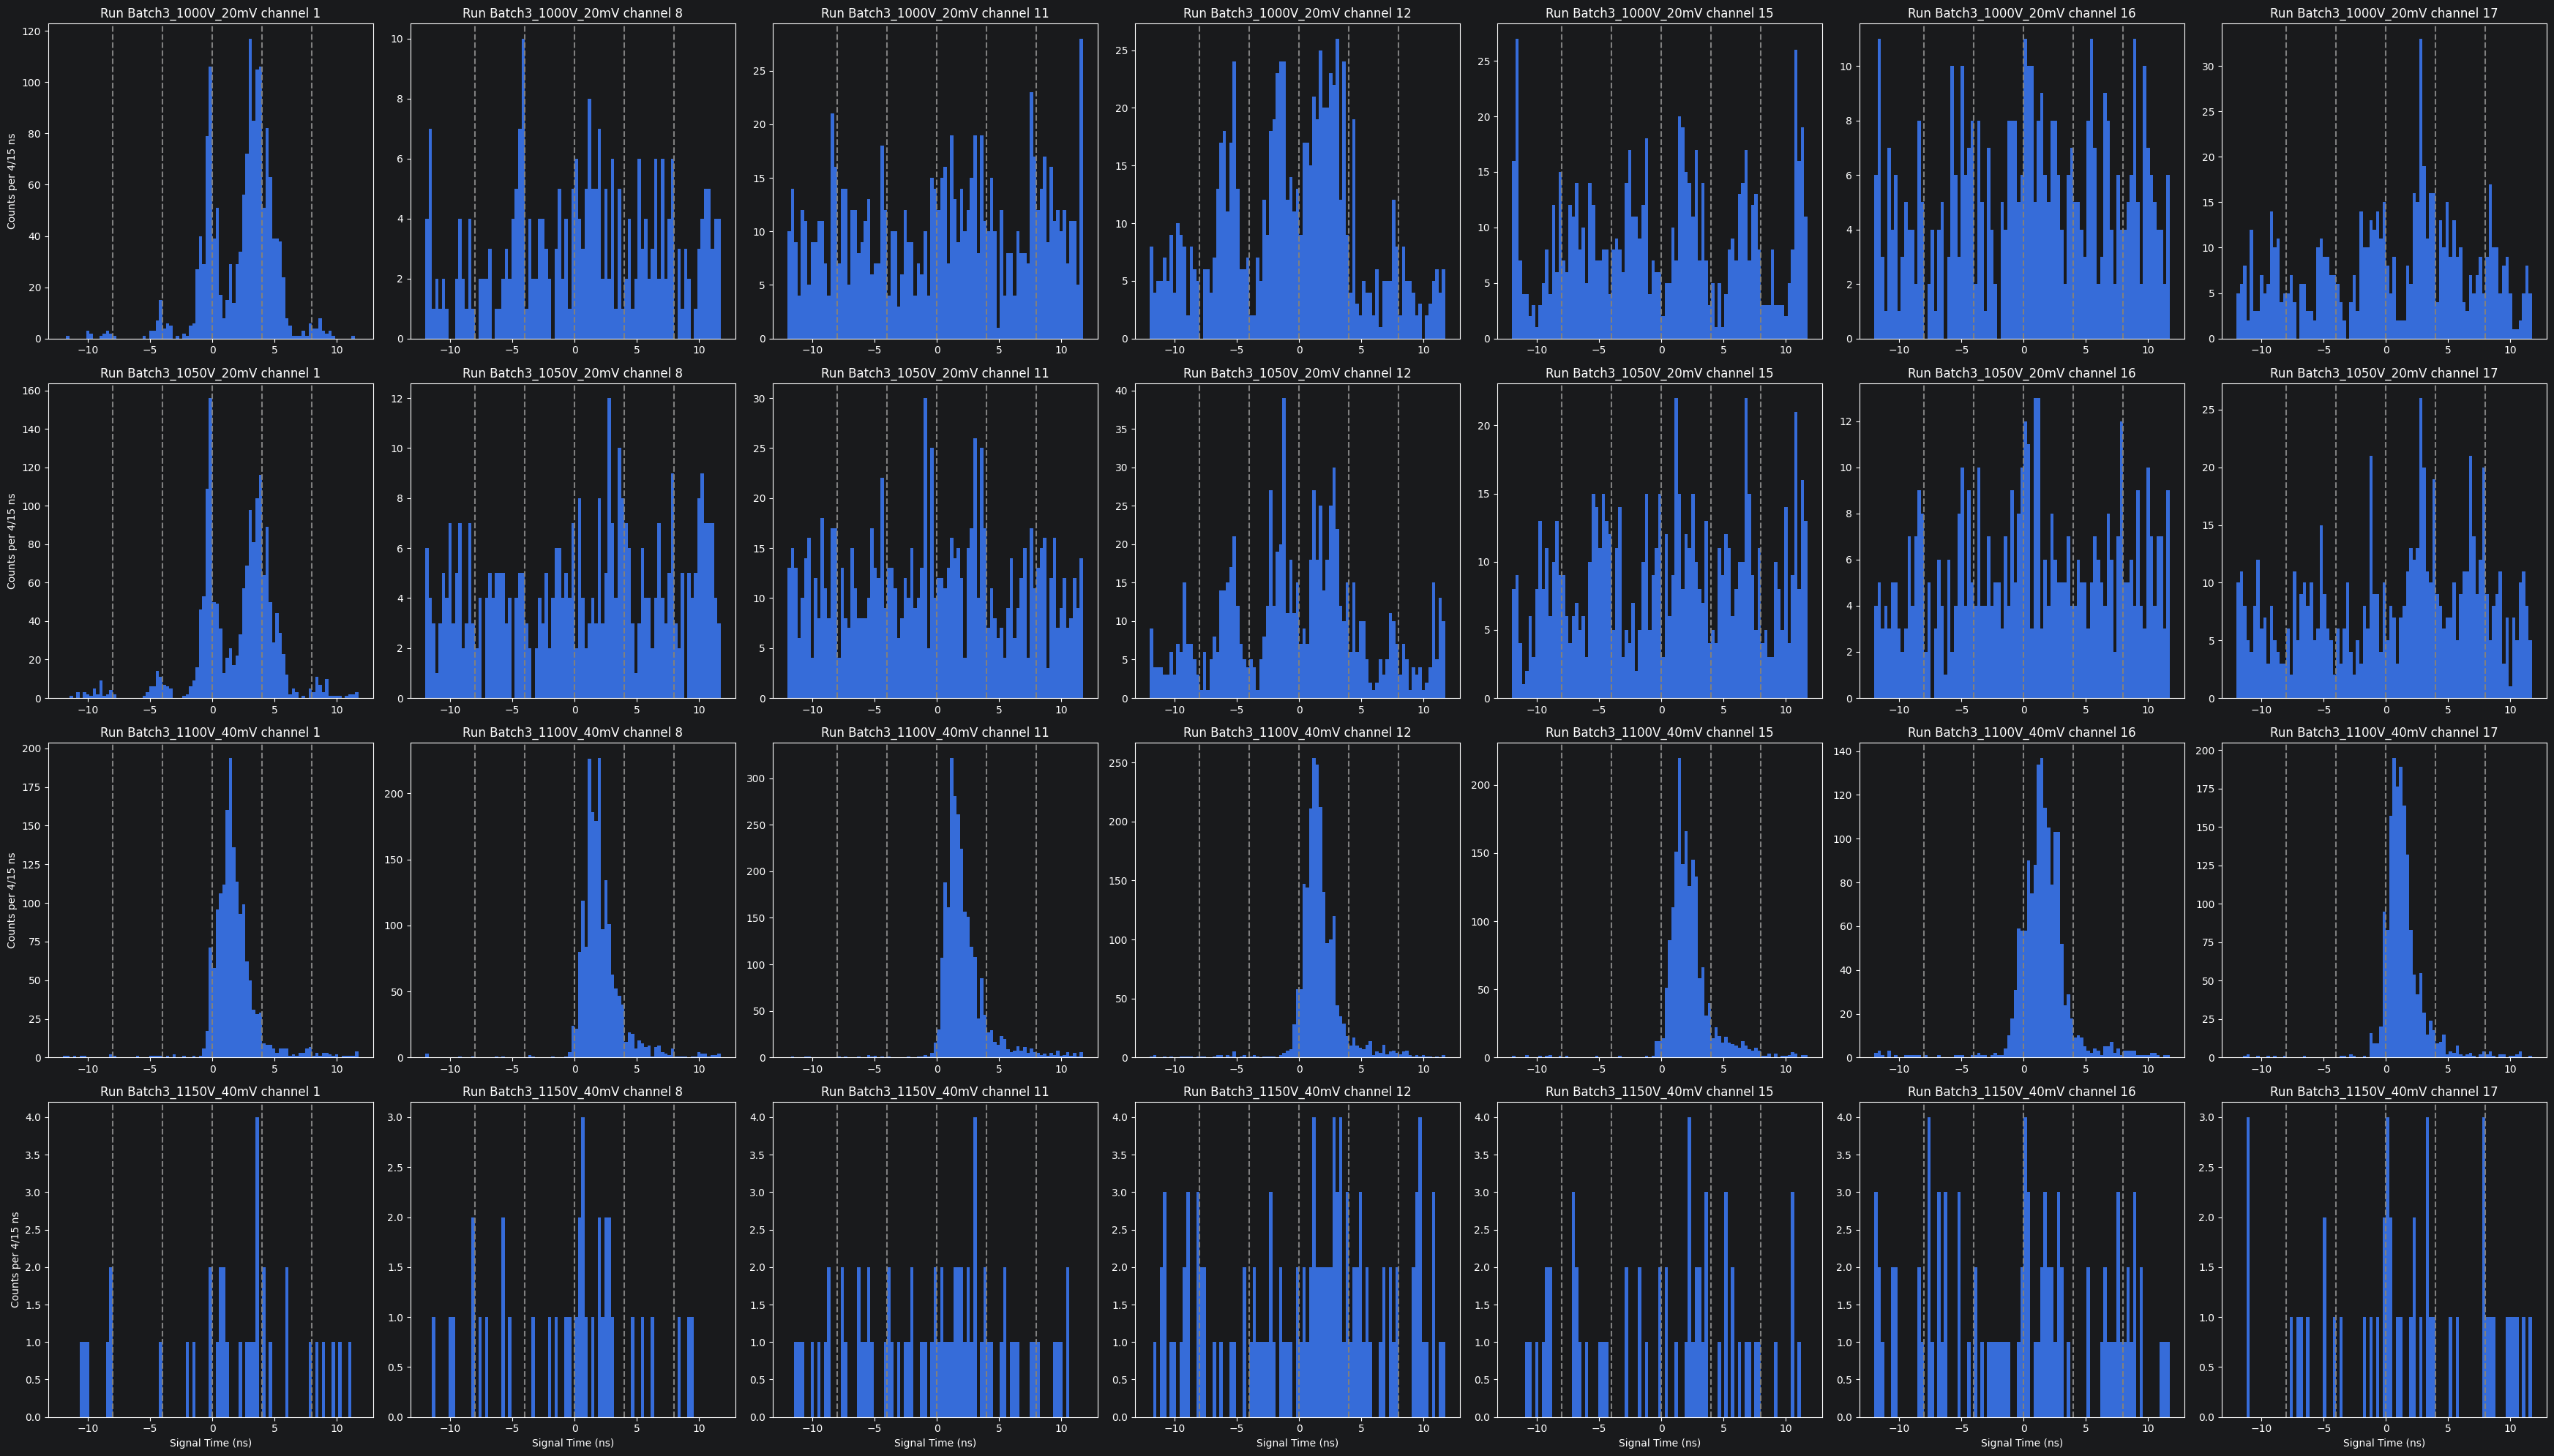

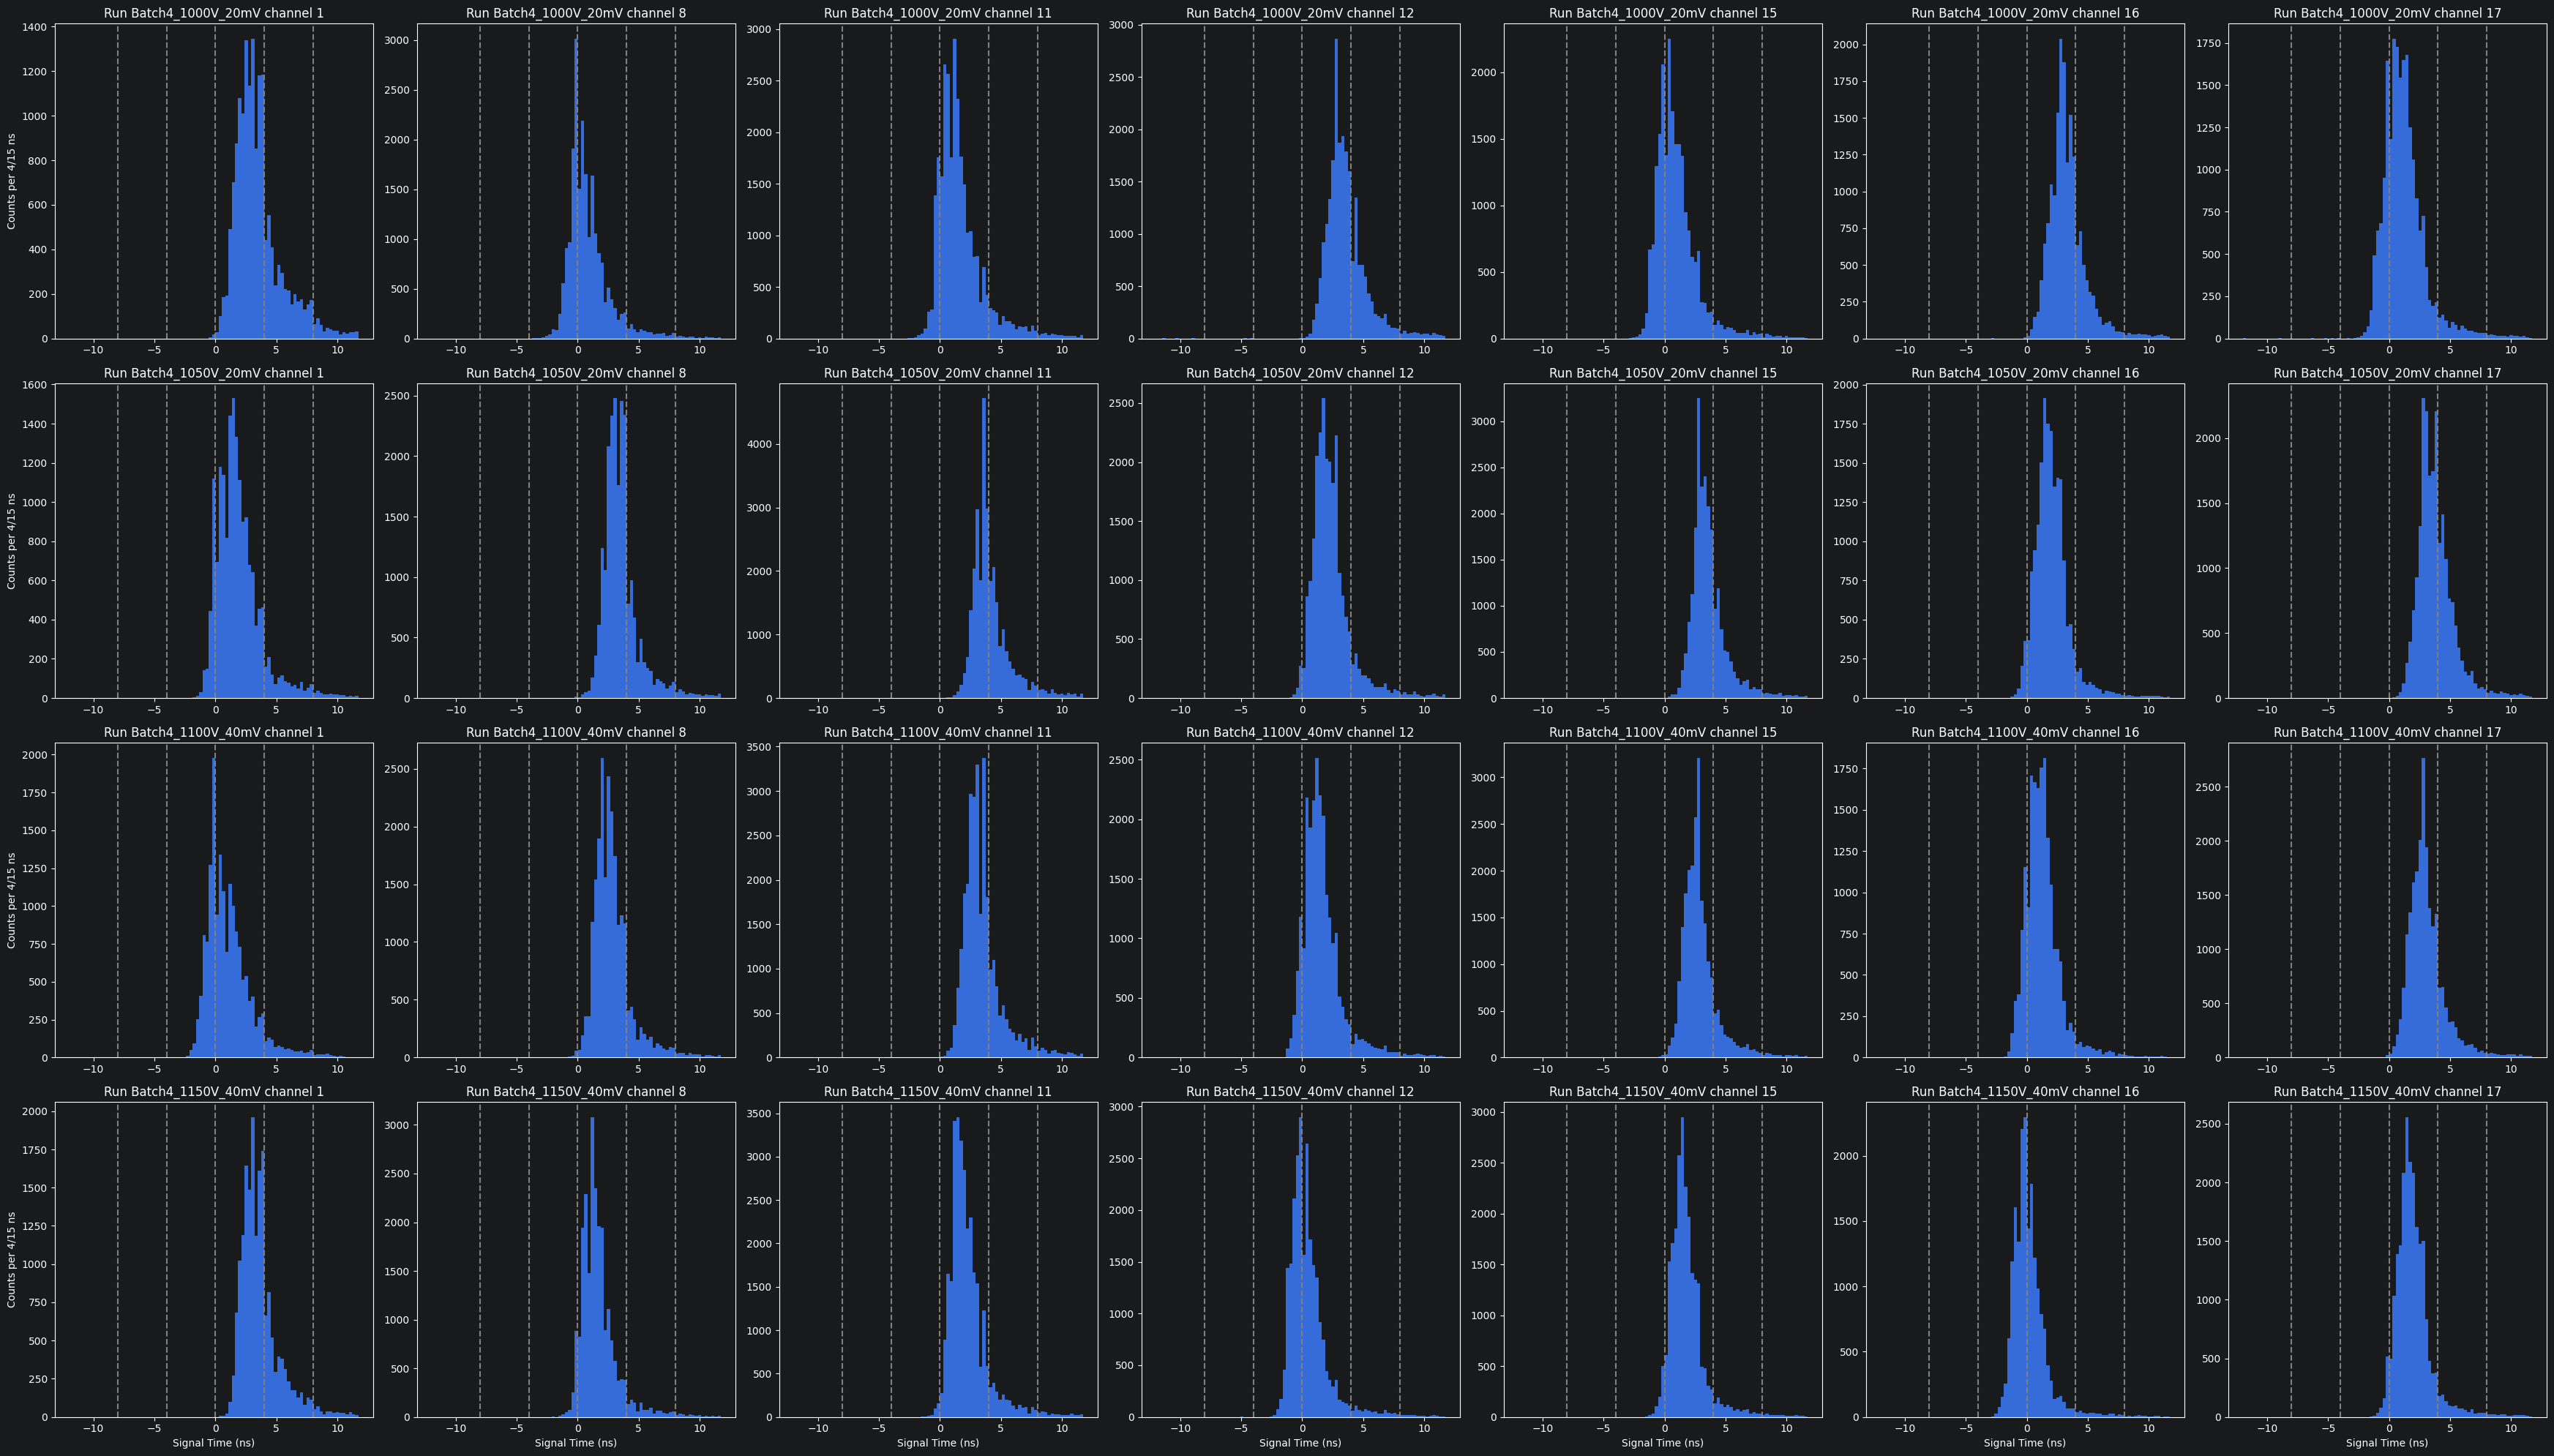

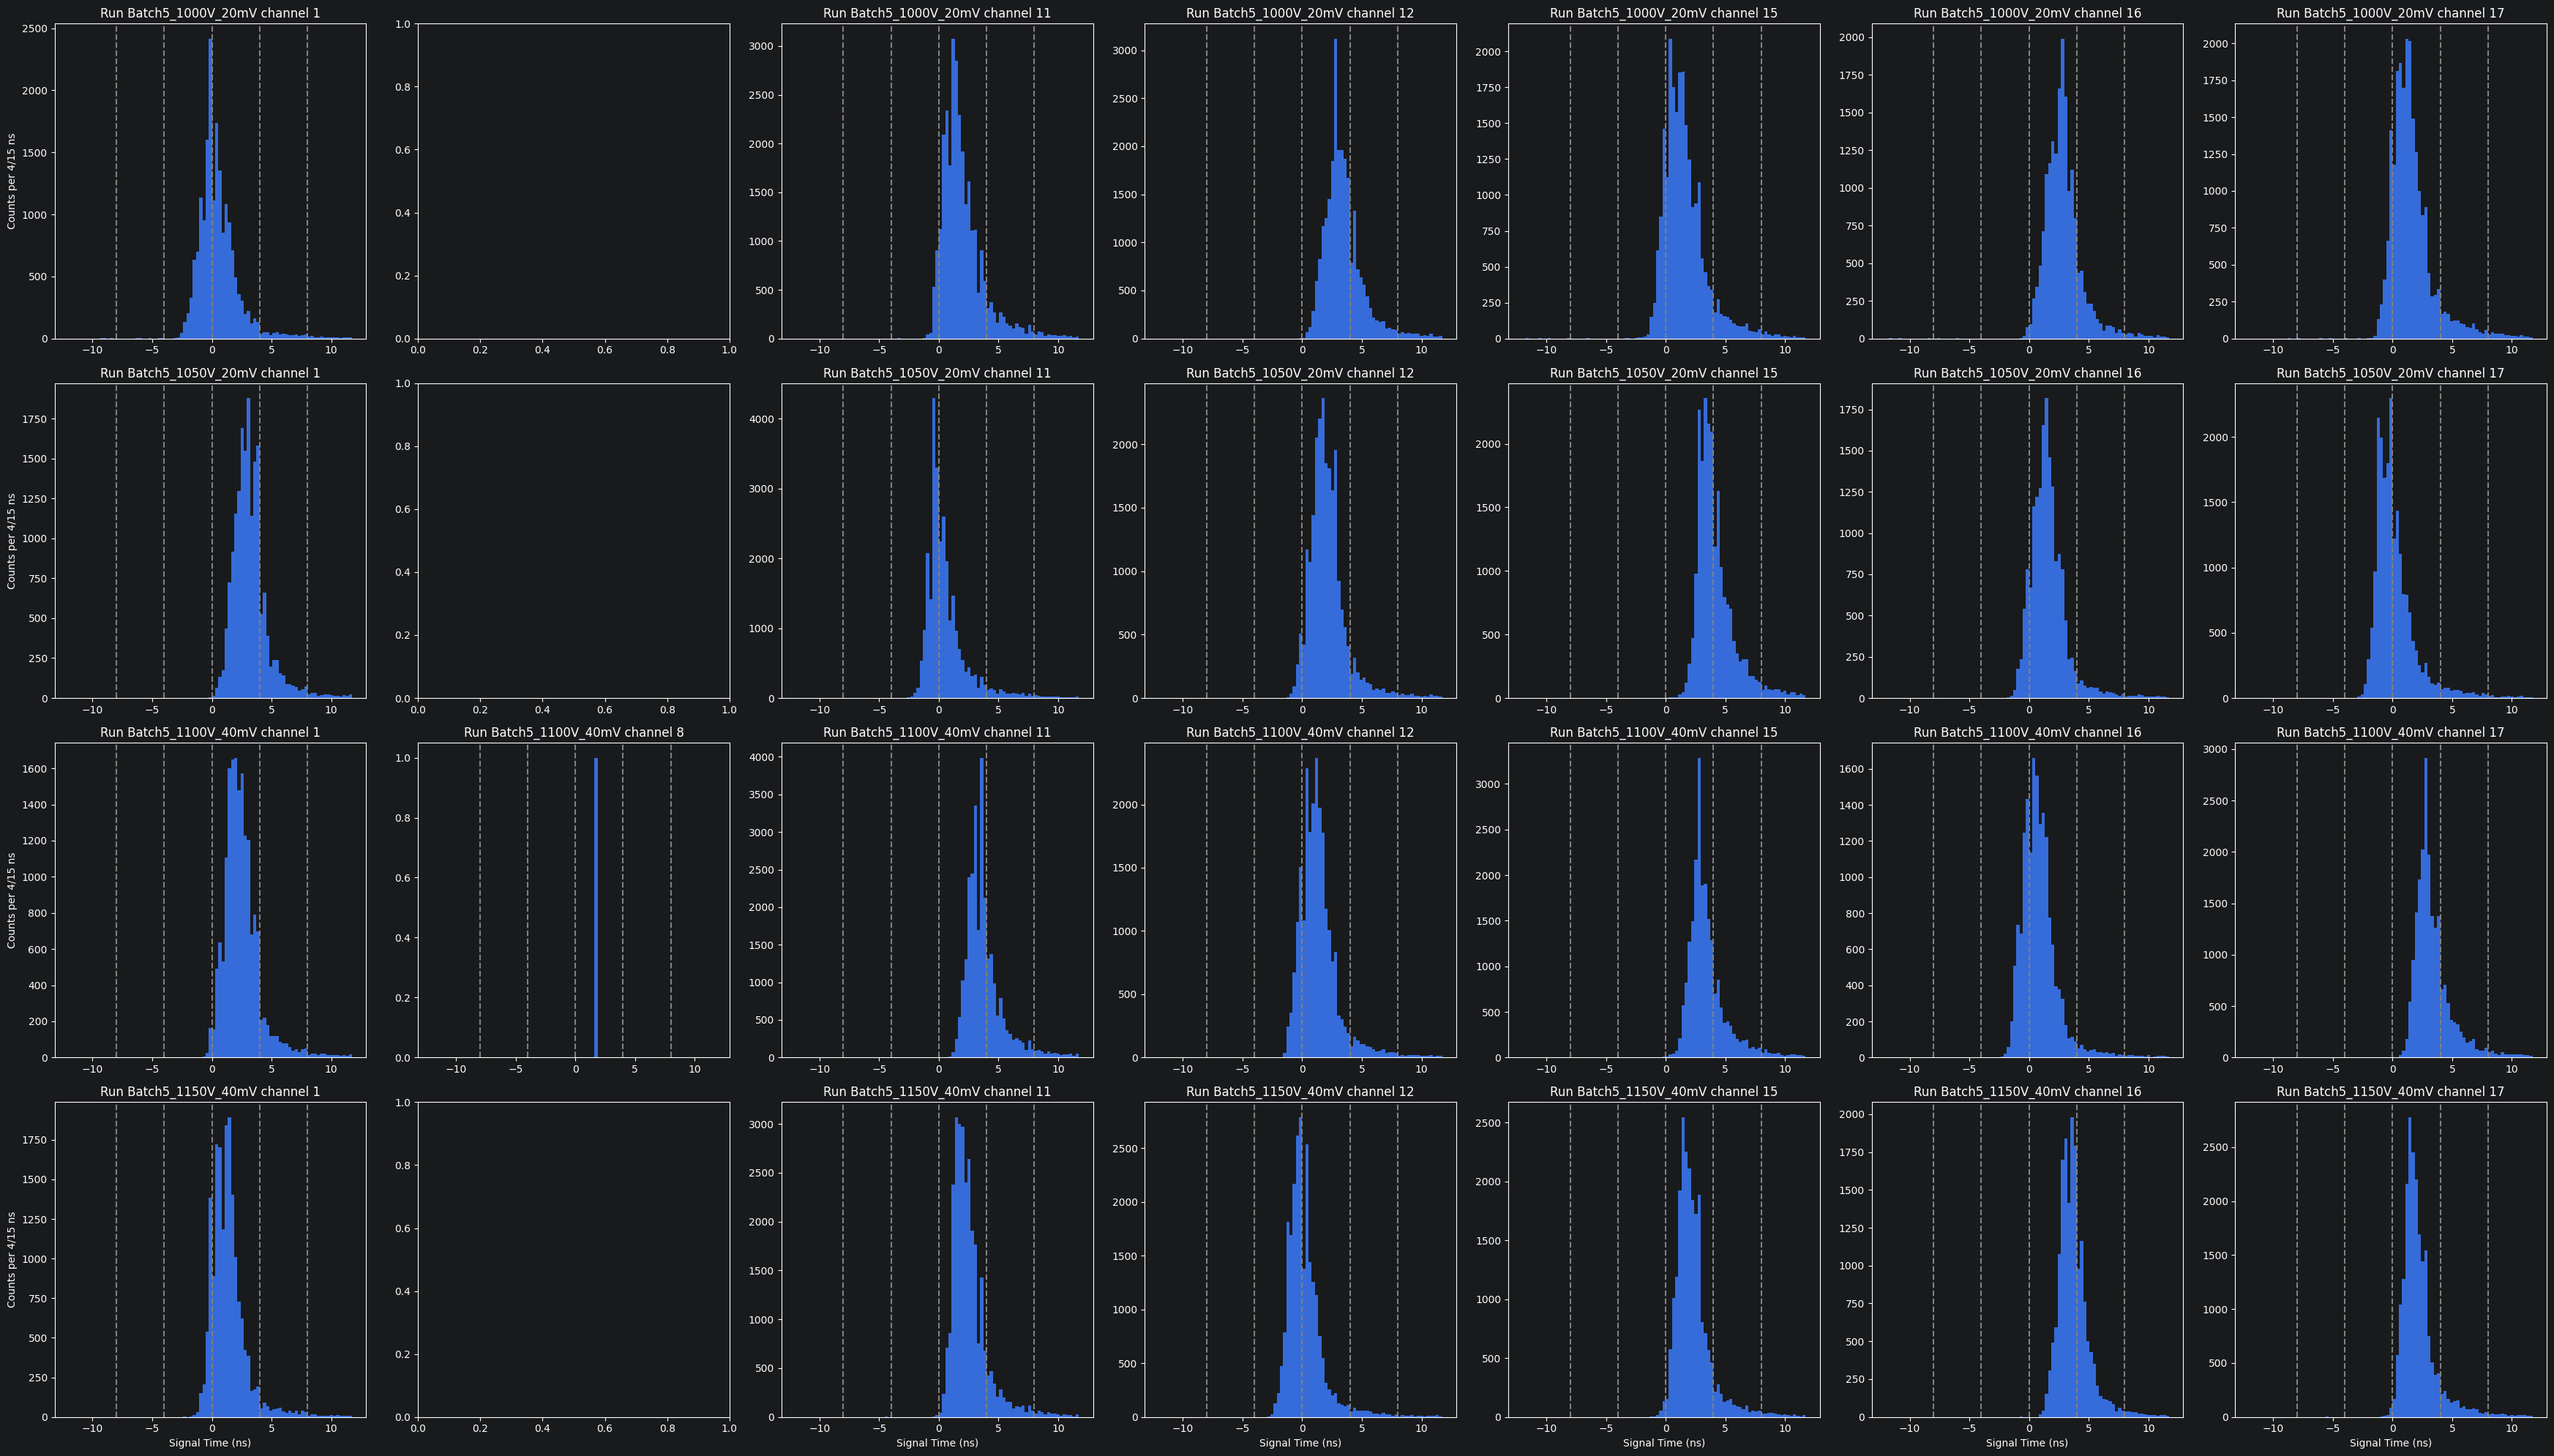

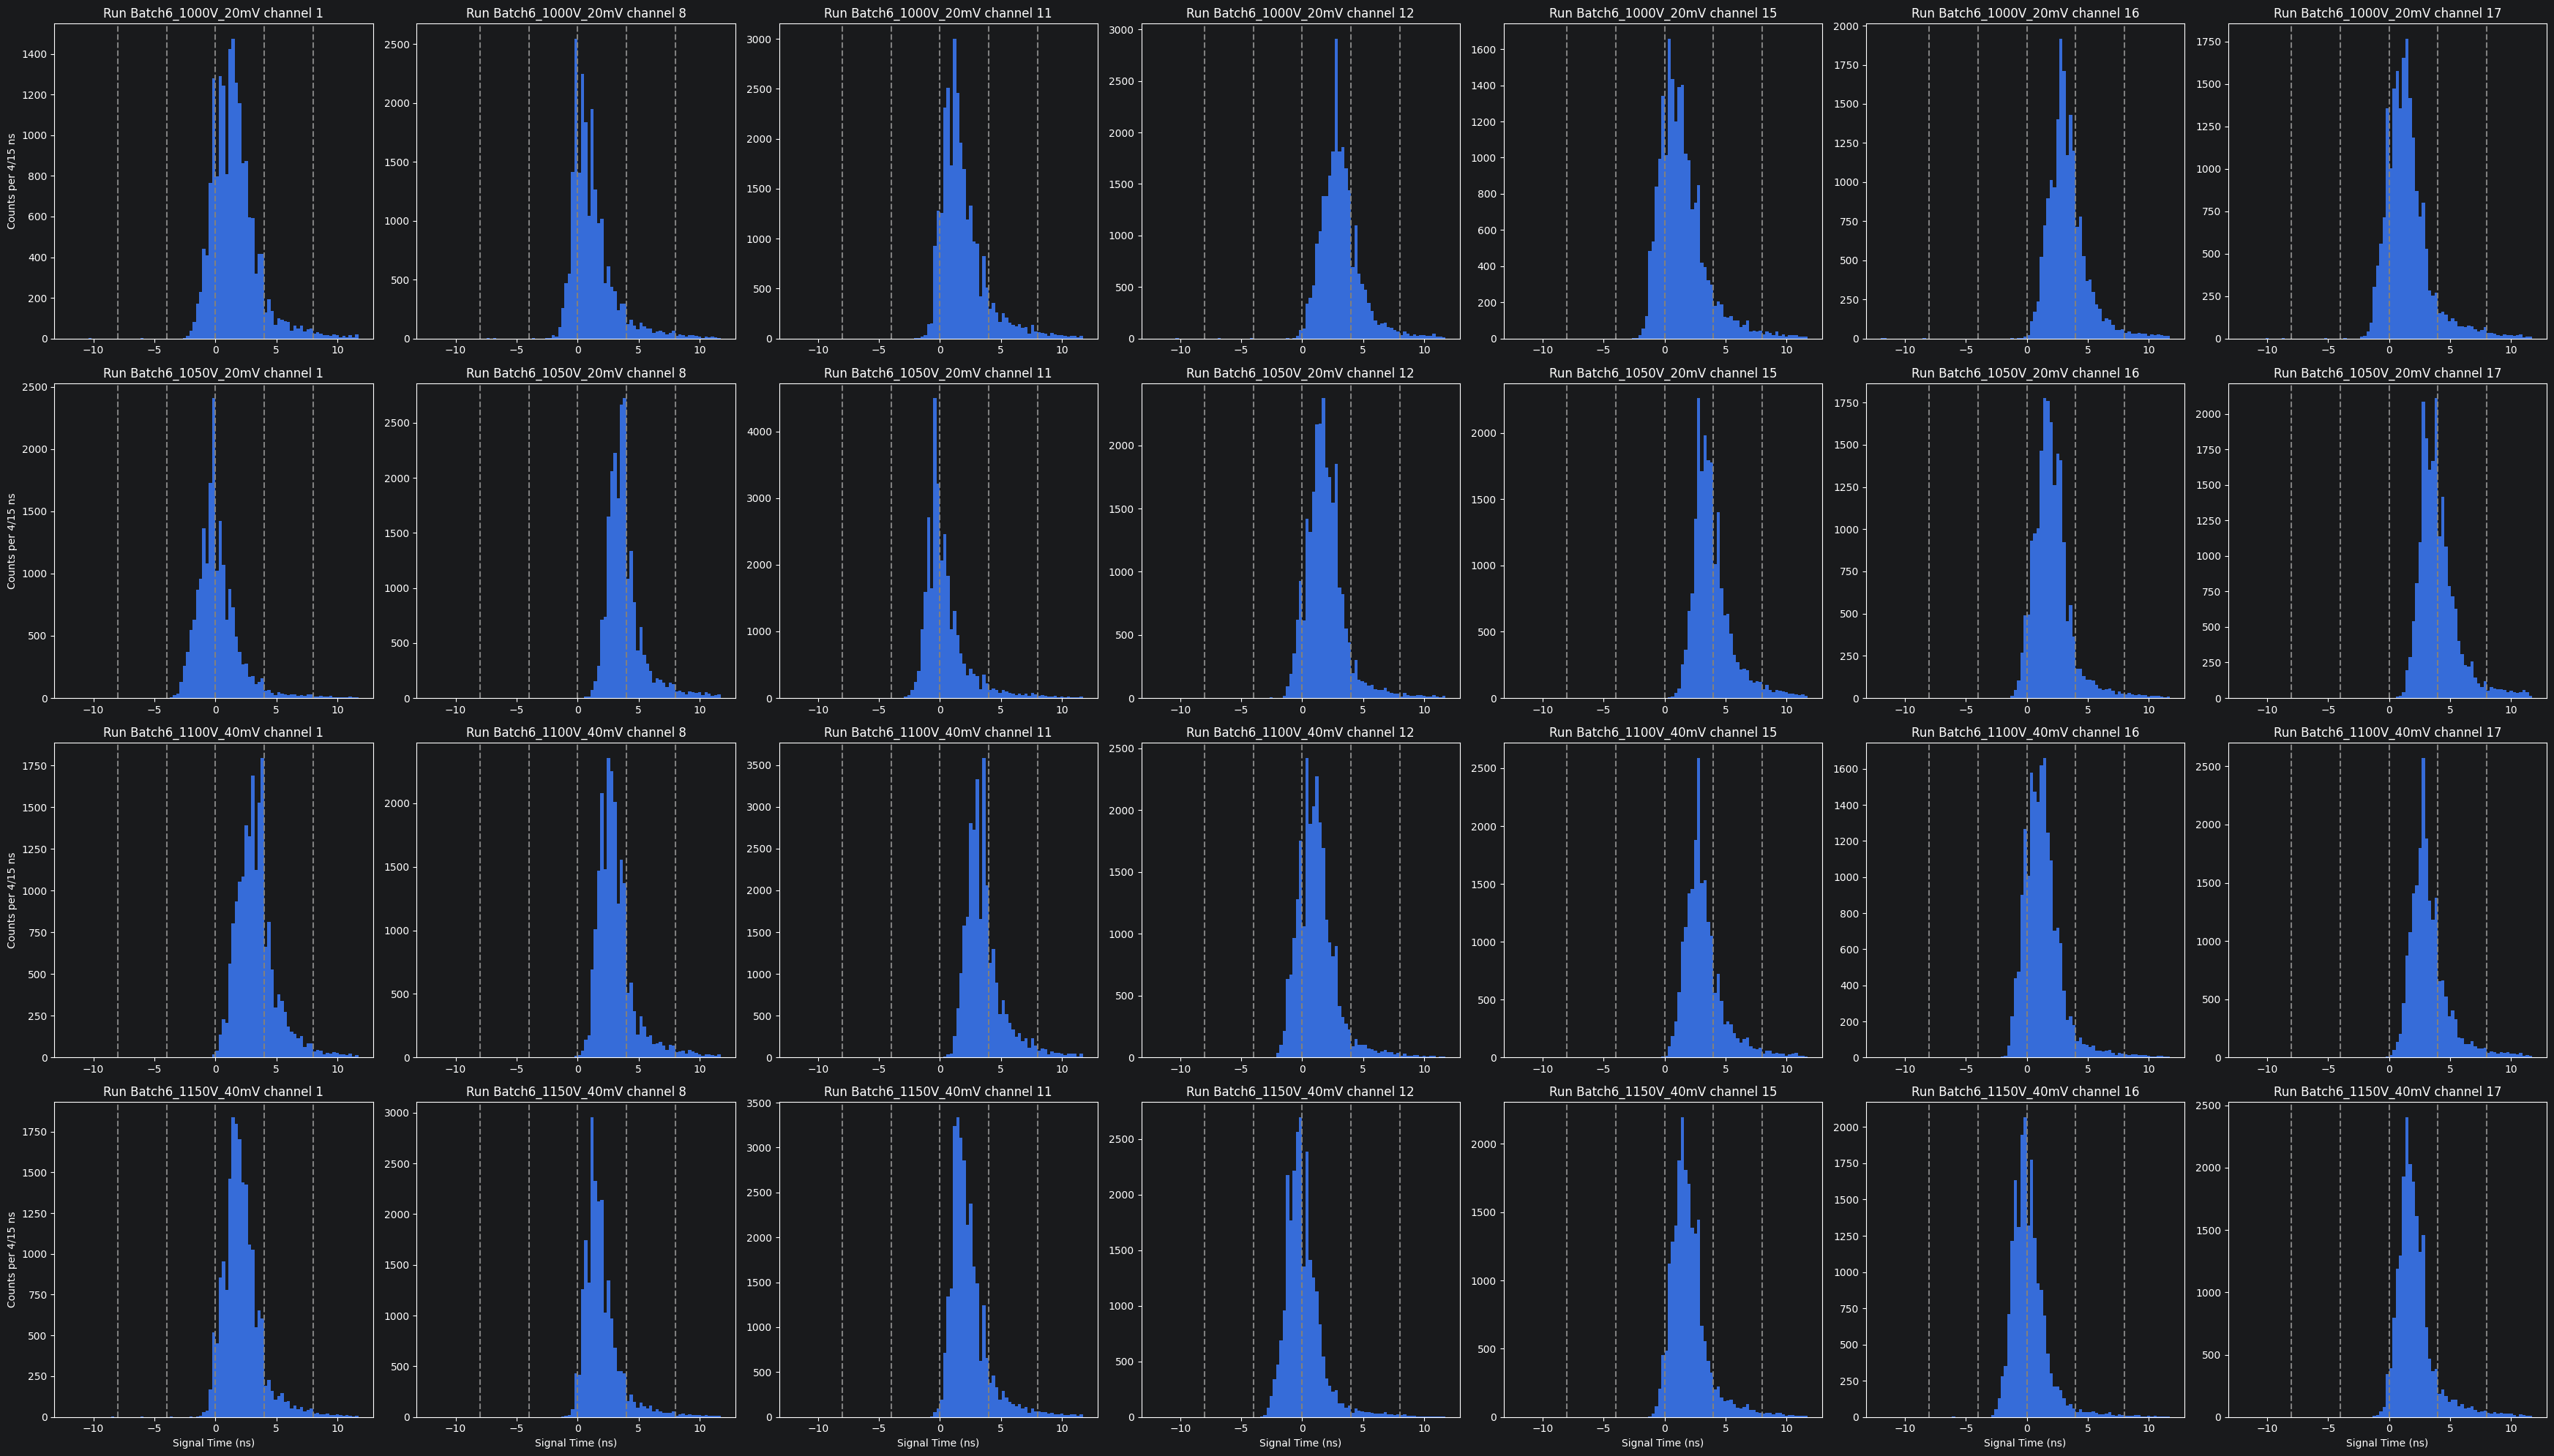

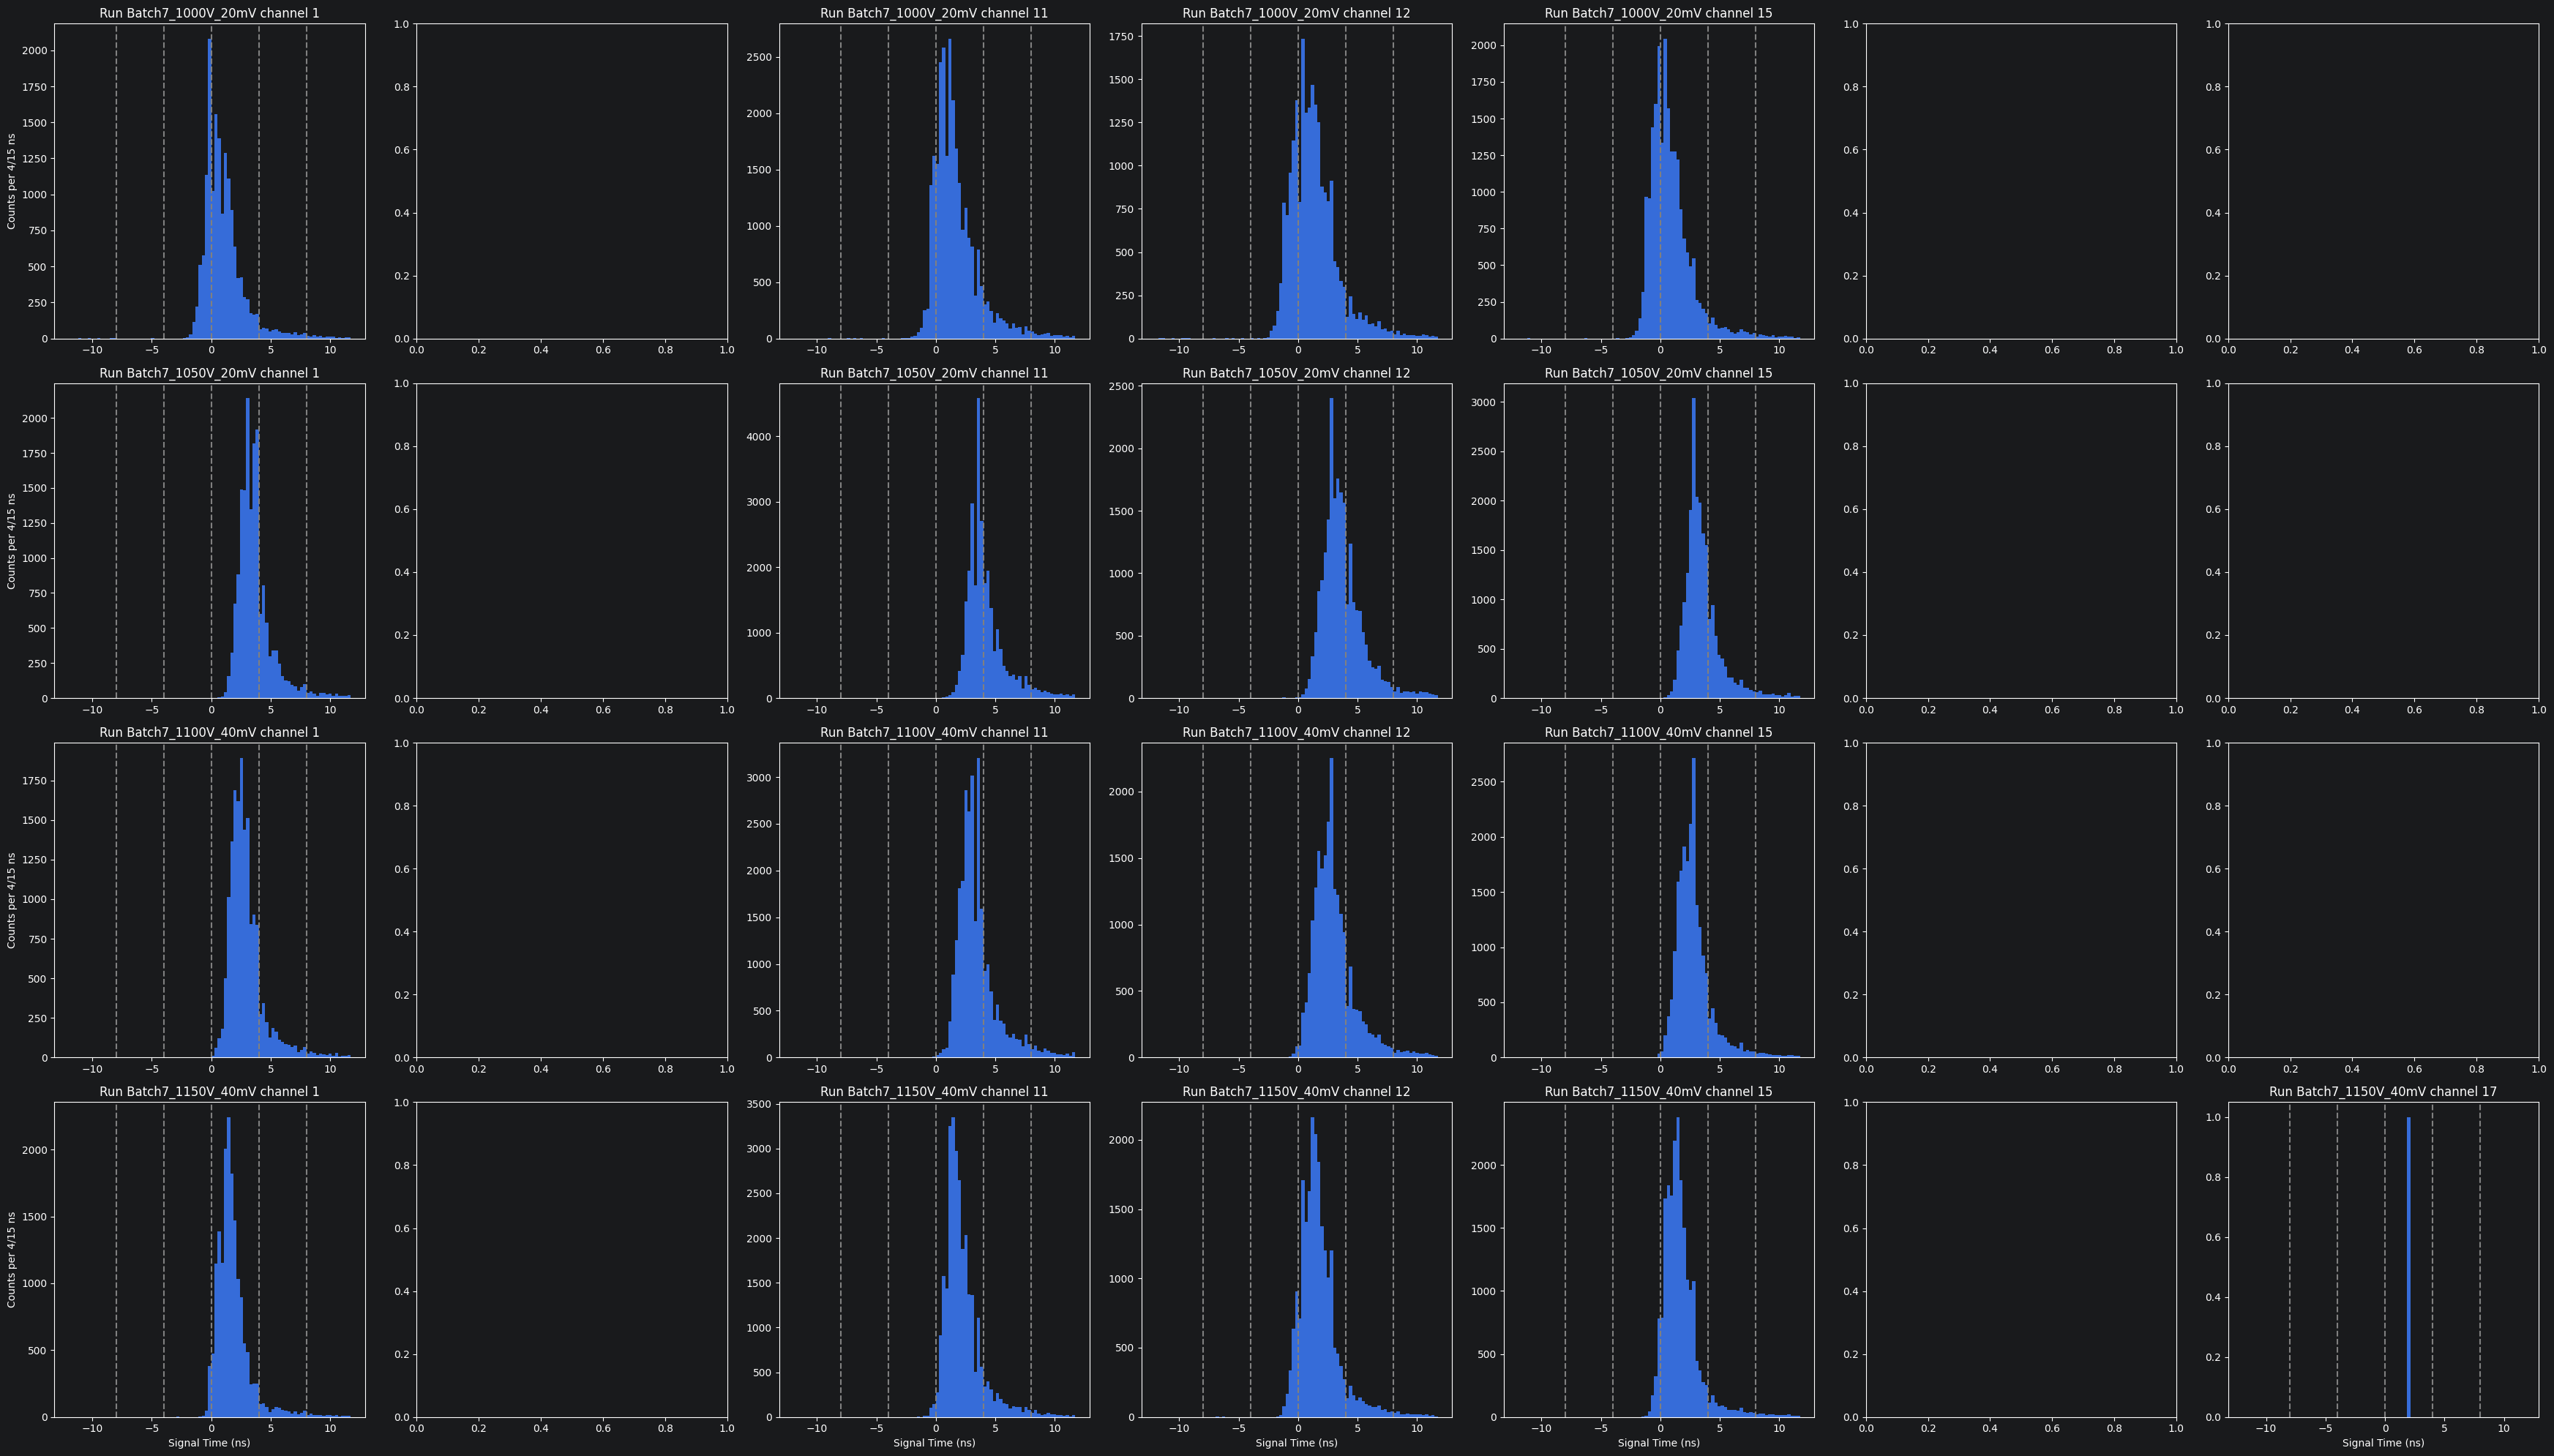

In [16]:
# Repeat the above plot for all channels and HV settings

for bn in range(7):
    data_set = get_data_set(bn)

    fig, axes = plt.subplots(4, 7, figsize=(35, 20))
    for hvn in range(4):
        for ic, channel in enumerate(channels):
            axis = axes[hvn,ic]
            run_name = f'Batch{batches[bn]}_{hvs[hvn]}'
            data = data_set[hvn][channel]

            if len(data['signal_times']) > 0:
                mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
                axis.hist(data['signal_times'][mask_led],bins=np.arange(-12.,12.,4./15))
                if hvn == 3:
                    axis.set_xlabel('Signal Time (ns)')
                if ic == 0:
                    axis.set_ylabel('Counts per 4/15 ns')
                axis.set_title(f'Run {run_name} channel {channel}')
                # add some gray vertical lines:
                for xval in [-8,-4,0,4,8]:
                    axis.axvline(xval, color='gray', linestyle='dashed')

    plt.tight_layout()

    plt.savefig(f'I:/fd2_analyses/202605/signal_time_distributions_batch{bn+1}.png')
    plt.show()


Time Range: 0 to 15.20


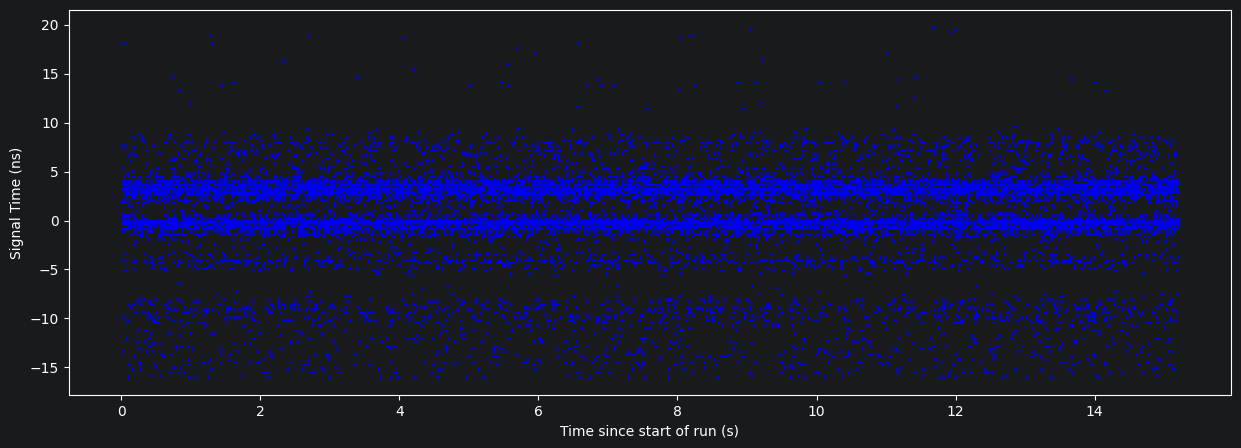

In [113]:
# Make a scatter plot of signal time vs time since start of run
mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)

time_min = np.min(data['pmt_times'])*4E-9
time_max = min(time_min+20,np.max(data['pmt_times'])*4E-9)
print(f"Time Range: 0 to {time_max-time_min:0.2f}")

plt.figure(figsize=(15, 5))
plt.scatter(data['pmt_times'][mask_led]*4E-9-time_min, data['signal_times'][mask_led], s=1, color='blue')
plt.xlabel('Time since start of run (s)')
plt.ylabel('Signal Time (ns)')
plt.savefig(f'I:/fd2_analyses/202605/signal_time_vs_time_run{run_name}_chan{channel:02d}.png')
plt.show()

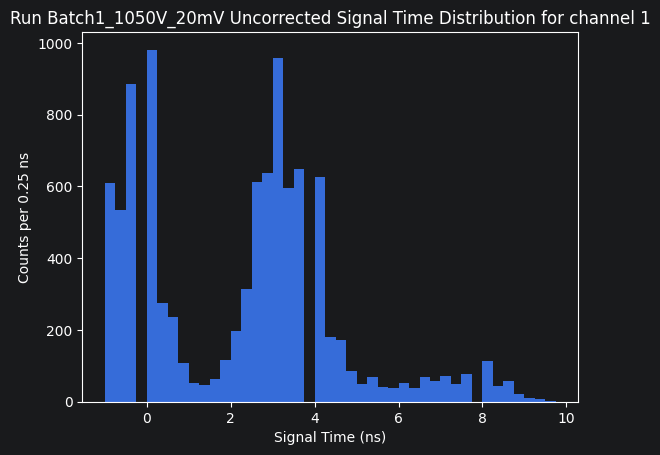

In [102]:
# Look at the signal times for the events near the expected LED flash time
#plt.hist(data['signal_times'][mask_led],bins=np.arange(-4.,20.,4./15))
plt.hist(data['signal_times'][mask_led],bins=np.arange(-1.,10.,0.25))
plt.xlabel('Signal Time (ns)')
plt.ylabel('Counts per 0.25 ns')
plt.title(f'Run {run_name} Uncorrected Signal Time Distribution for channel {channel}')
plt.savefig(f'I:/fd2_analyses/202605/signal_time_distribution_run{run_name}_chan{channel:02d}LED_bin25.png')
plt.show()

In [94]:
channel = 17

C:\Users\karlen\AppData\Local\Temp\ipykernel_27636\1329385960.py:56: RuntimeWarning: divide by zero encountered in divide
  popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
C:\Users\karlen\AppData\Local\Temp\ipykernel_27636\1329385960.py:56: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
C:\Users\karlen\AppData\Local\Temp\ipykernel_27636\1329385960.py:62: RuntimeWarning: invalid value encountered in divide
  y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))


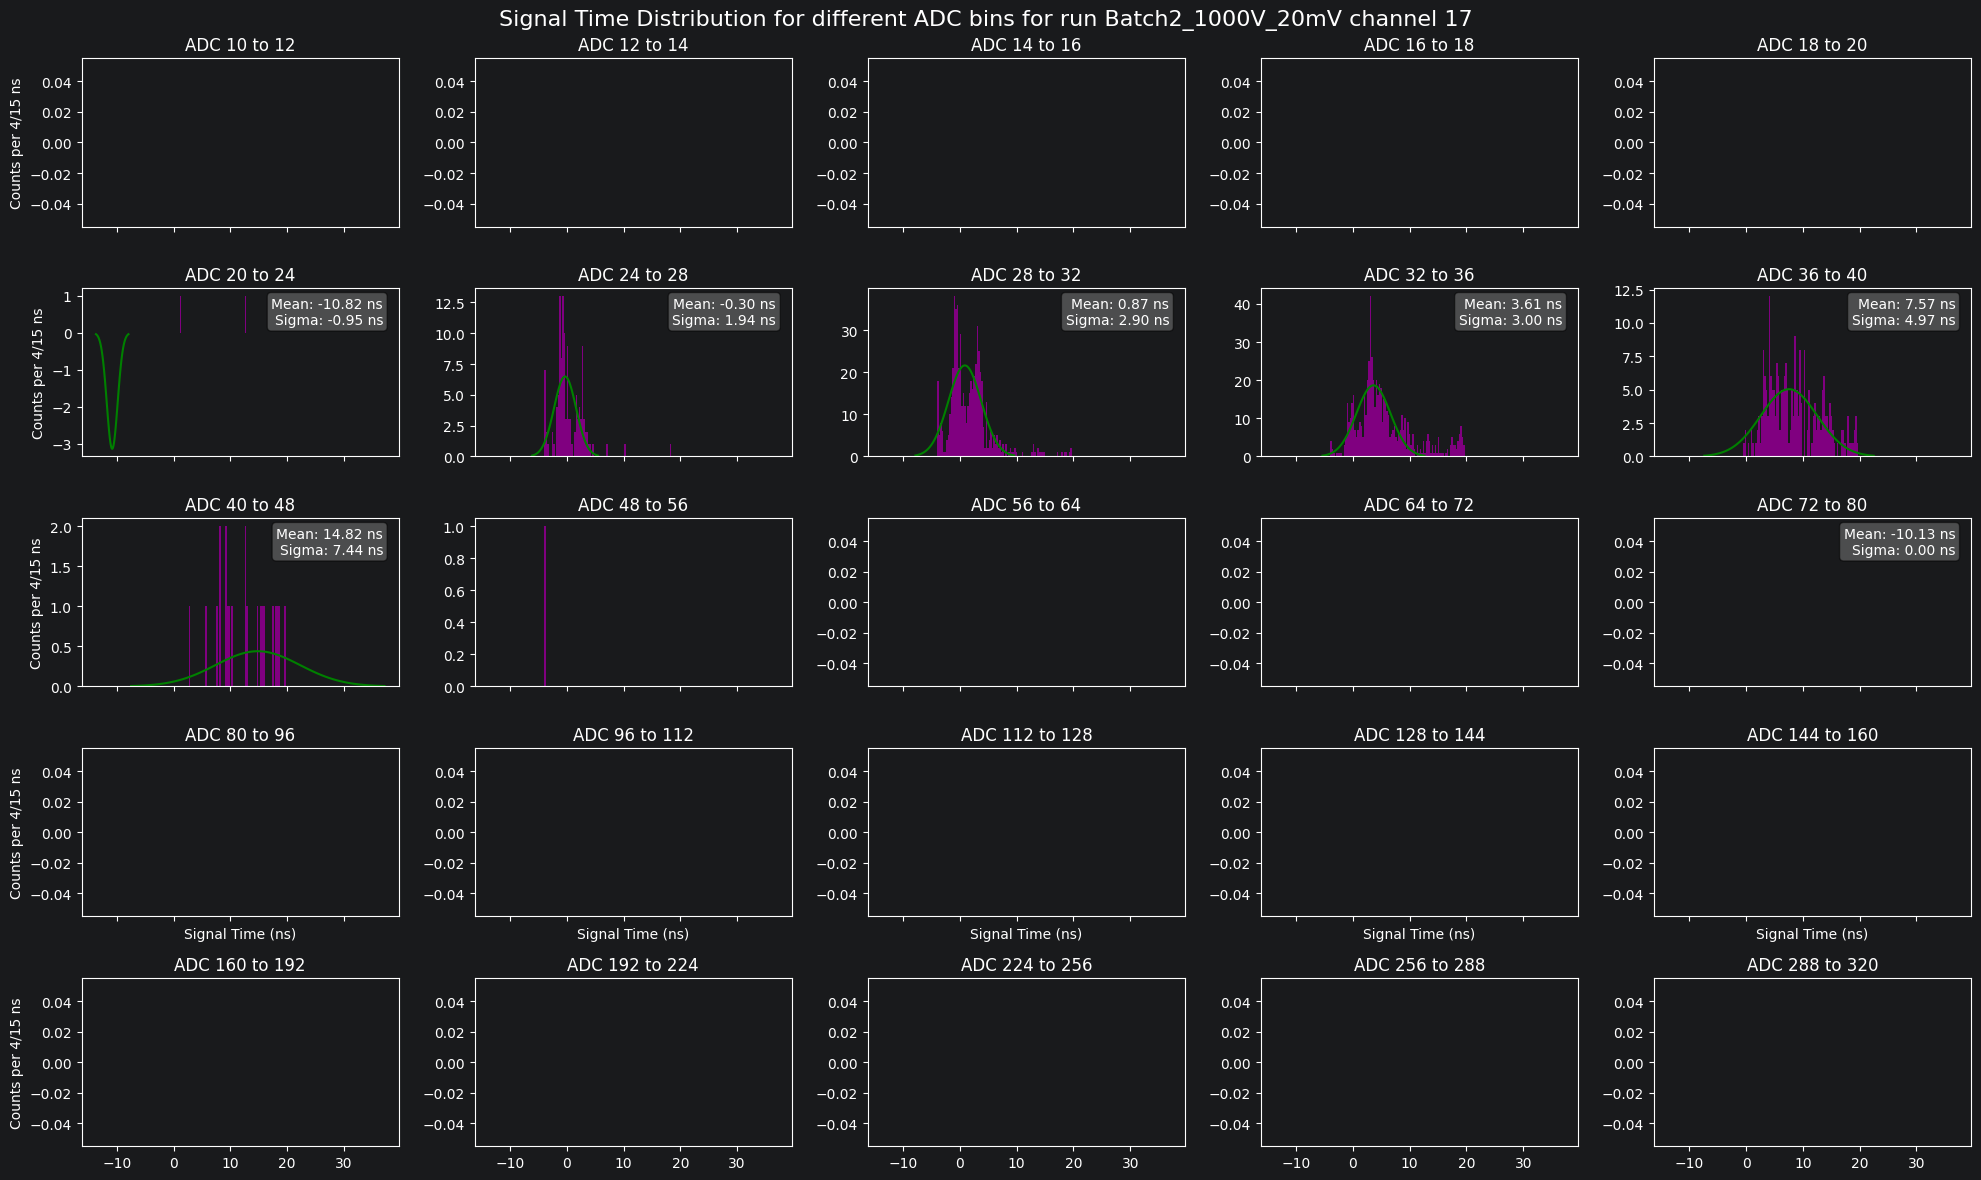

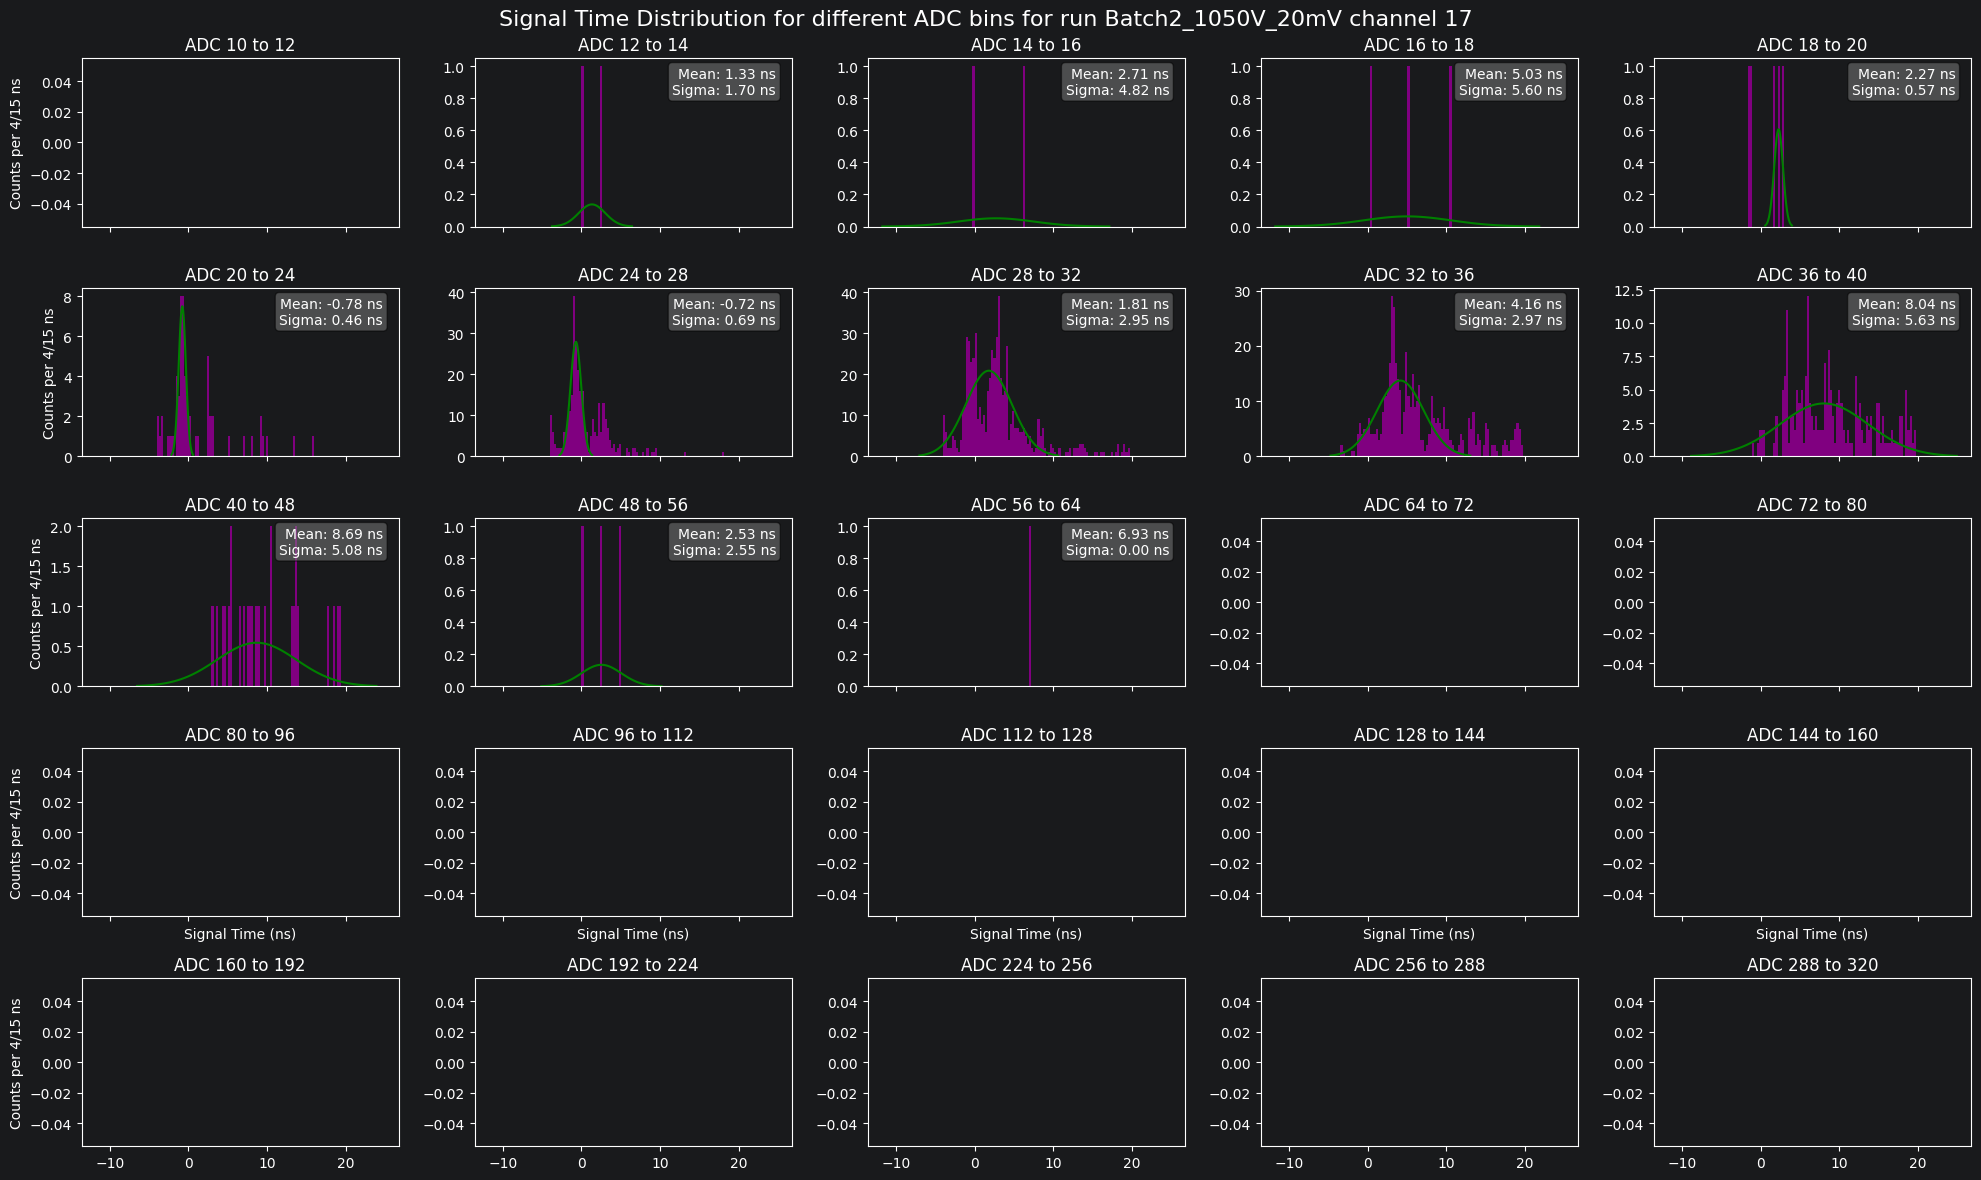

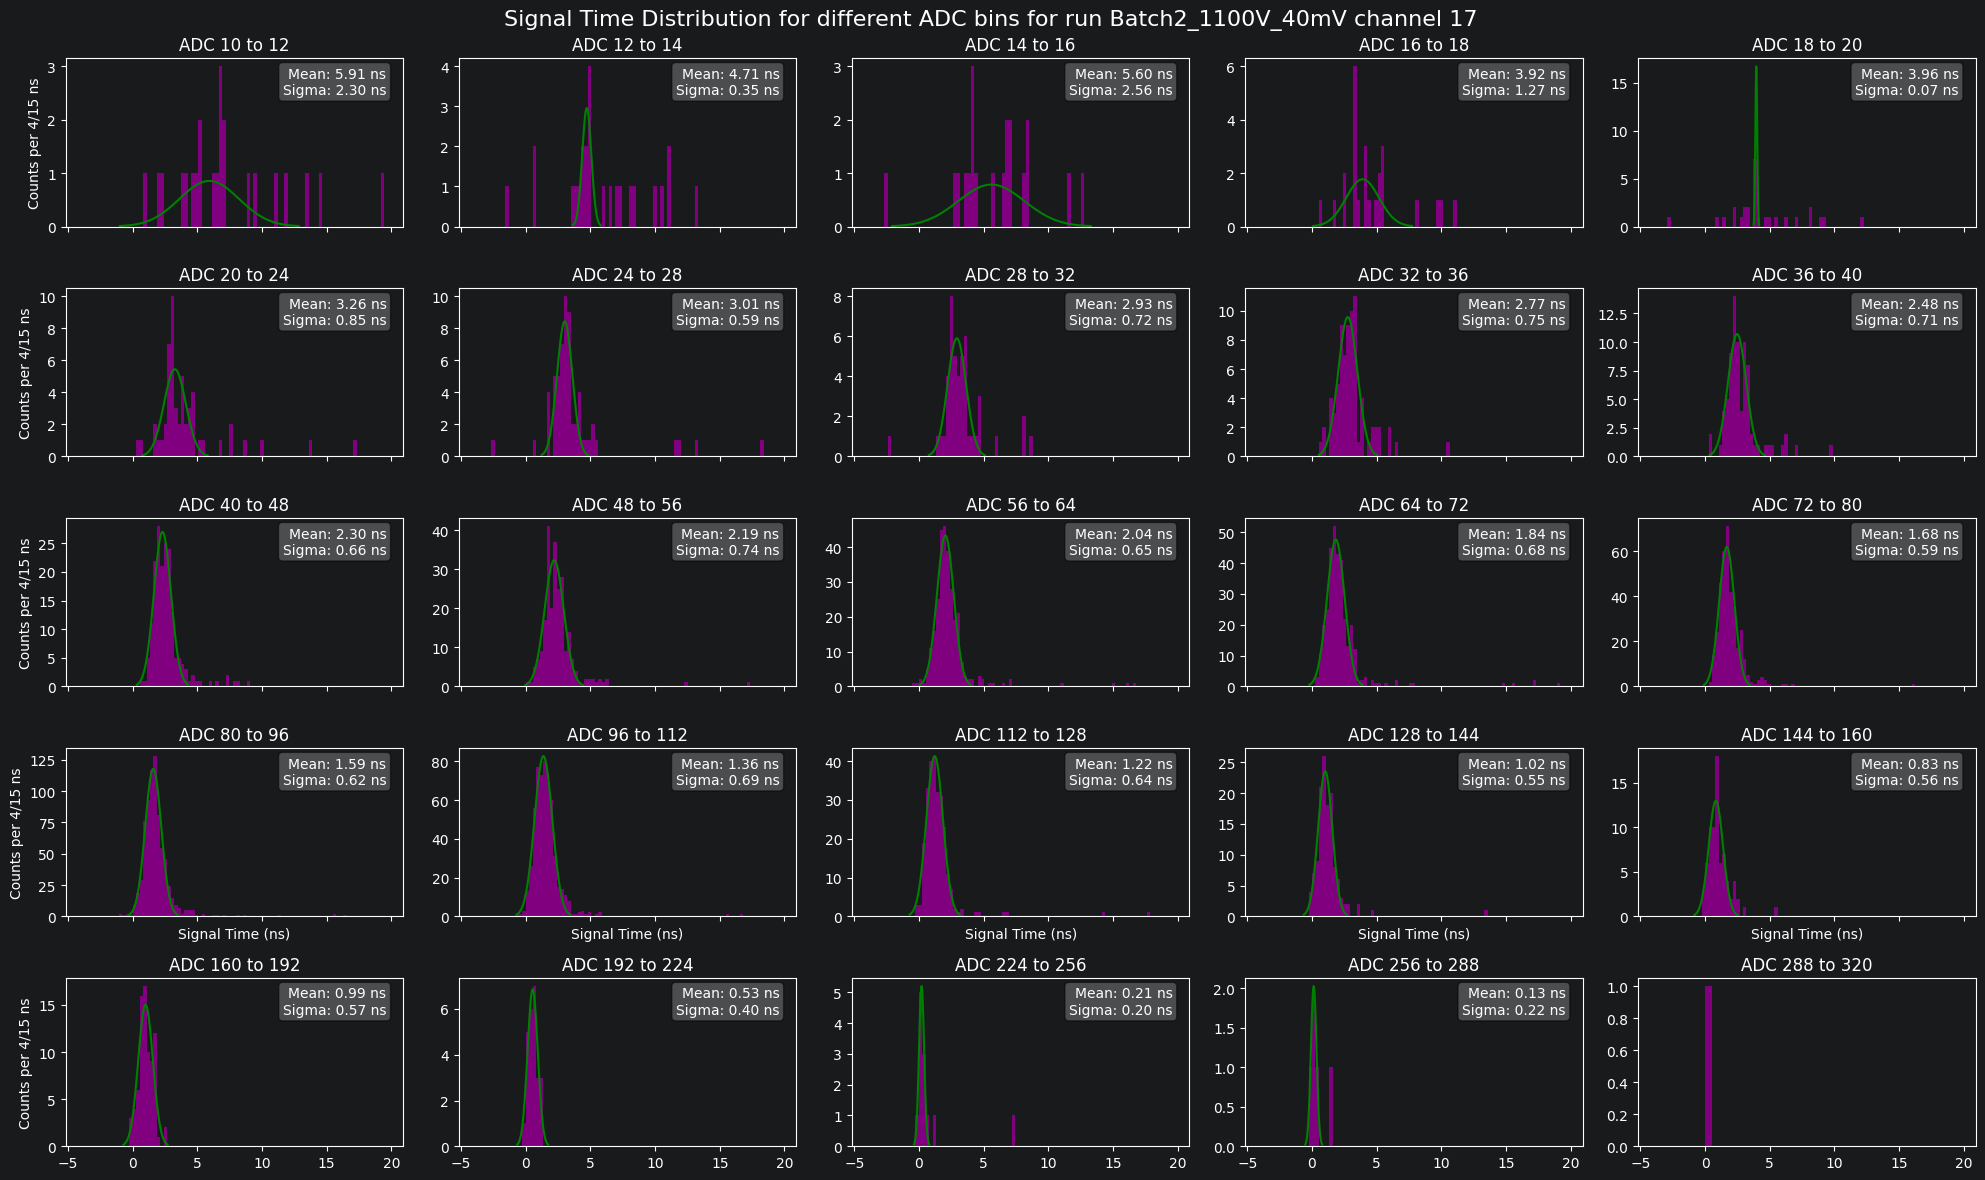

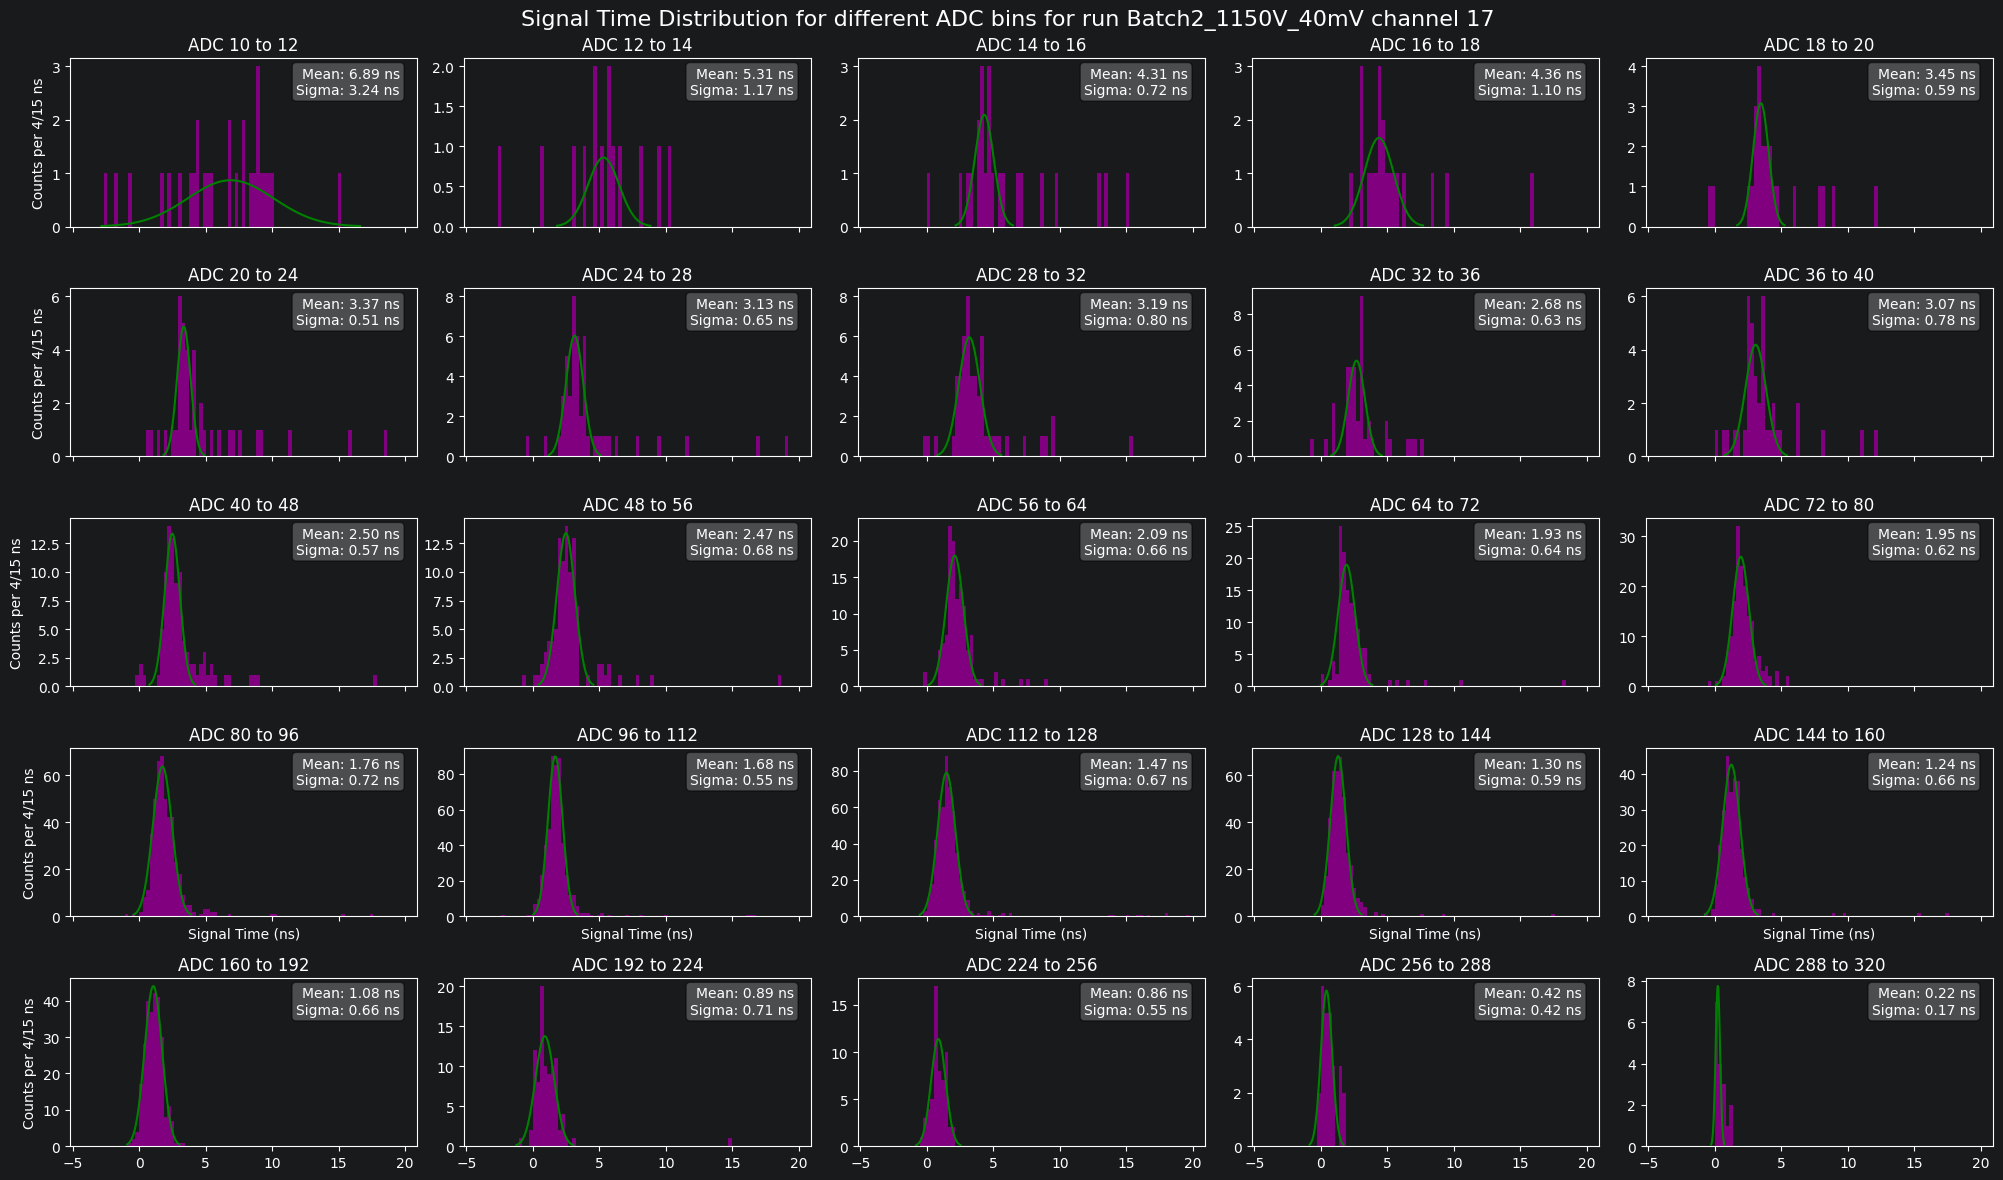

In [95]:
# The mean and standard deviation of the signal times will depend on the amplitude of the pulse.
# Look at the signal time distribution as a function of ADC value, by considering bins of ADC values.
# For each bin, plot the distribution of signal times, and fit to a Gaussian to extract the mean and standard deviation
# of the signal time for that ADC bin.

time_walk_correction_funcs = {}
time_walk_correction_ranges = {}
time_walk_correction_means_sel = {}
time_walk_correction_stds_sel = {}
time_walk_correction_bin_centers_sel = {}

adc_offset = 250
adc_bin_min = 10

# Use more bins at low ADC where the correction is more substantial
bin_width = 2
adc_bin_edges = [adc_bin_min]
for row in range(5):
    for col in range(5):
        adc_bin_edges.append(adc_bin_edges[-1] + bin_width)
    if row < 4:
        bin_width *= 2

for hvn in range(len(hvs)):
    run_name = f'Batch{batches[bn]}_{hvs[hvn]}'
    data = data_set[hvn][channel]

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

    n_signal_times = []
    mean_signal_times = []
    std_signal_times = []

    # Make subplots in 4x5 grid, in each plot show the signal time distribution for a different ADC bin
    fig, ax = plt.subplots(5, 5, figsize=(20, 12), sharex=True)

    for i in range(len(adc_bin_edges)-1):
        axis = ax[i//5, i%5]
        bin = [adc_bin_edges[i]+adc_offset, adc_bin_edges[i+1]+adc_offset]
        mask_adc_bin = ((data['adcs'] >= bin[0]) & (data['adcs'] < bin[1]) & mask_led)
        signal_times_adc_bin = data['signal_times'][mask_adc_bin]
        axis.hist(signal_times_adc_bin, bins=np.arange(-4.,20.,4./15), color='purple')
        axis.set_title(f'ADC {bin[0]-adc_offset} to {bin[1]-adc_offset}')

        if i%5 == 0:
            axis.set_ylabel('Counts per 4/15 ns')
        if i//5 == 3:
            axis.set_xlabel('Signal Time (ns)')
        # Fit to a Gaussian
        if len(signal_times_adc_bin) > 0:
            hist, bin_edges = np.histogram(signal_times_adc_bin, bins=np.arange(-4.,20.,4./15))
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            # Initial guess for fit parameters: amplitude, mean, stddev
            p0 = [np.max(hist), np.mean(signal_times_adc_bin), np.std(signal_times_adc_bin)]
            try:
                popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
                n_signal_times.append(hist.sum())
                mean_signal_times.append(popt[1])
                std_signal_times.append(popt[2])
                # Plot the fit
                x_fit = np.linspace(popt[1]-3*popt[2], popt[1]+3*popt[2], 100)
                y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
                axis.plot(x_fit, y_fit, color='green', linestyle='-')
                # Add a text box with mean and sigma values shown
                textstr = '\n'.join((
                    f'Mean: {popt[1]:.2f} ns',
                    f'Sigma: {popt[2]:.2f} ns'))
                props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
                axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)
            except RuntimeError:
                n_signal_times.append(0)
                mean_signal_times.append(np.nan)
                std_signal_times.append(np.nan)
        else:
            n_signal_times.append(0)
            mean_signal_times.append(np.nan)
            std_signal_times.append(np.nan)
    plt.suptitle(f'Signal Time Distribution for different ADC bins for run {run_name} channel {channel}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'I:/fd2_analyses/202605/time_vs_adc_run{run_name}_chan{channel:02d}.png')
    plt.show()

    adc_bin_centers_sel = []
    mean_signal_times_sel = []
    std_signal_times_sel = []
    fit_range = [-1,-1]
    for i in range(len(adc_bin_edges)-1):
        bin = [adc_bin_edges[i],adc_bin_edges[i+1]]
        if n_signal_times[i] > 50:
            adc_bin_centers_sel.append((bin[0]+bin[1])/2)
            mean_signal_times_sel.append(mean_signal_times[i])
            std_signal_times_sel.append(std_signal_times[i])
            if fit_range[0] < 0:
                fit_range[0] = adc_bin_edges[i]
            fit_range[1] = adc_bin_edges[i+1]

    if 1==2:
        time_walk_correction_func = interp1d(adc_bin_centers_sel, mean_signal_times_sel, kind='cubic', fill_value='extrapolate')
        time_walk_correction_funcs[run_name] = time_walk_correction_func
        time_walk_correction_ranges[run_name] = fit_range
        time_walk_correction_means_sel[run_name] = mean_signal_times_sel
        time_walk_correction_stds_sel[run_name] = std_signal_times_sel
        time_walk_correction_bin_centers_sel[run_name] = adc_bin_centers_sel


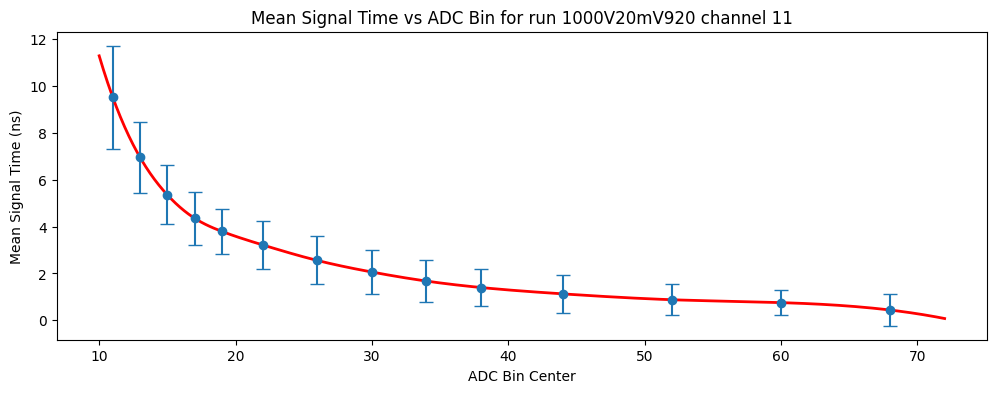

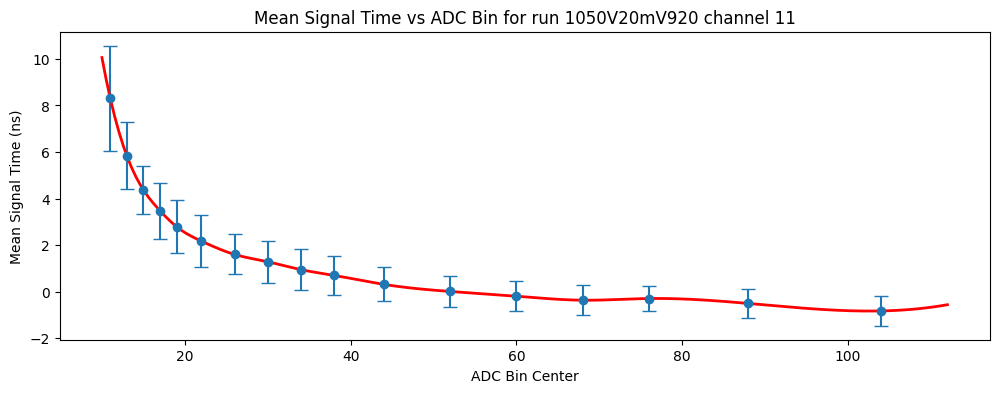

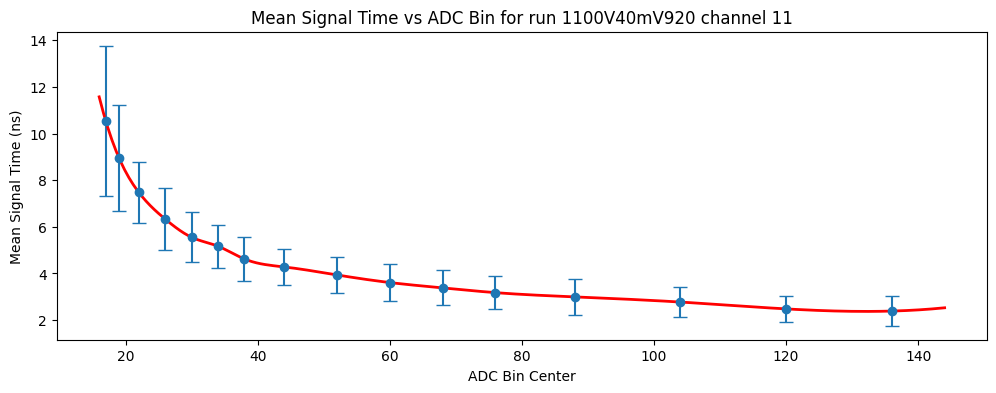

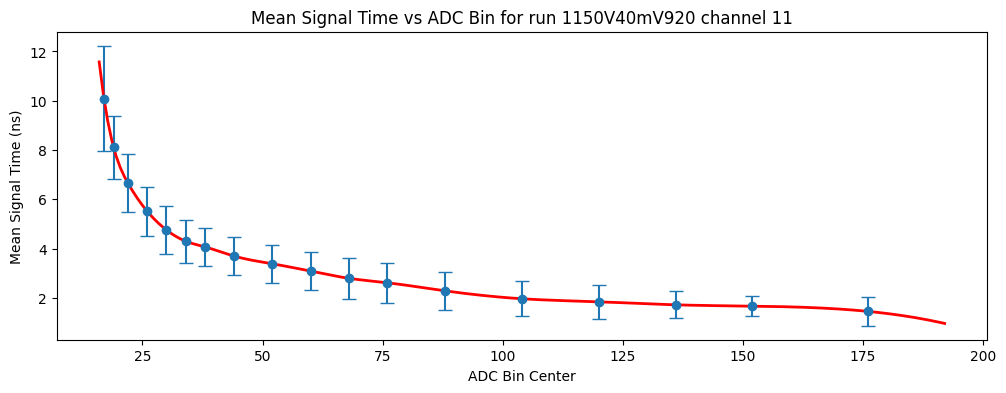

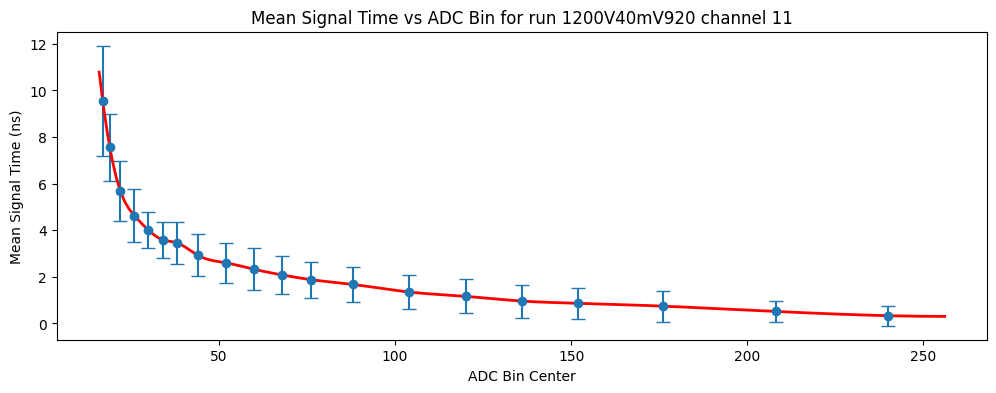

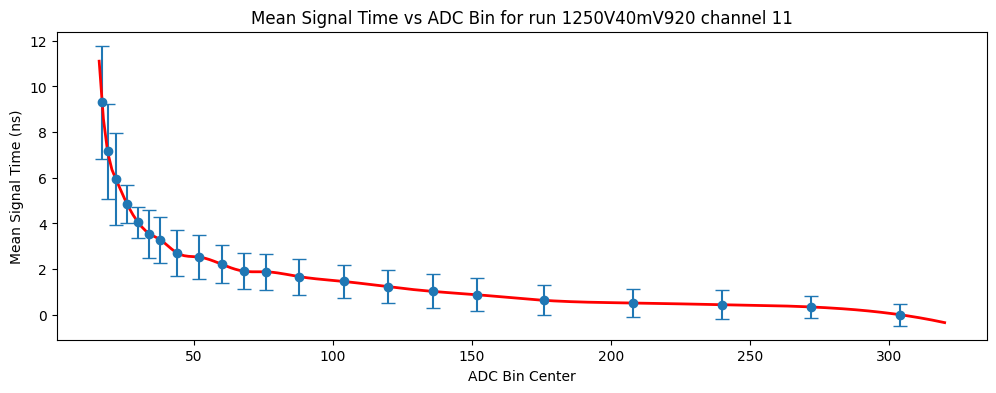

In [22]:
# Plot the mean signal time as a function of ADC bin, and show the standard deviation as error bars

for run_name in time_walk_correction_funcs.keys():

    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    mean_signal_times_sel = time_walk_correction_means_sel[run_name]
    std_signal_times_sel = time_walk_correction_stds_sel[run_name]
    adc_bin_centers_sel = time_walk_correction_bin_centers_sel[run_name]

    plt.figure(figsize=(12, 4))
    plt.errorbar(adc_bin_centers_sel, mean_signal_times_sel, yerr=std_signal_times_sel, fmt='o', capsize=5)
    x_fit = np.linspace(fit_range[0], fit_range[1], 200)
    y_fit = time_walk_correction_func(x_fit)
    plt.plot(x_fit, y_fit, color='red', linestyle='-', lw=2, label='Interpolation Function')

    plt.xlabel('ADC Bin Center')
    plt.ylabel('Mean Signal Time (ns)')
    plt.title(f'Mean Signal Time vs ADC Bin for run {run_name} channel {channel}')
    plt.savefig(f'I:/fd2_analyses/mean_signal_time_vs_adc_bin_run{run_name}_chan{channel:02d}.png')
    plt.show()

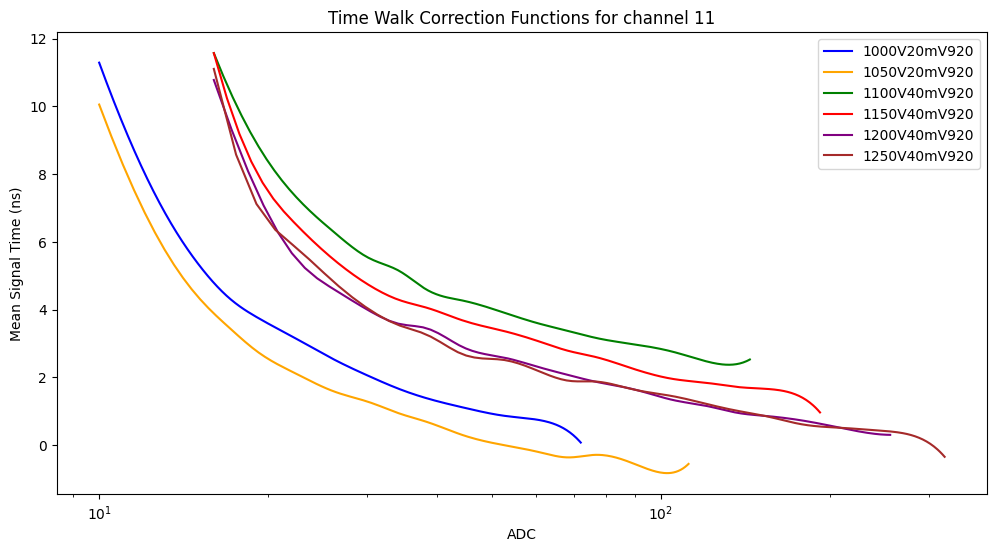

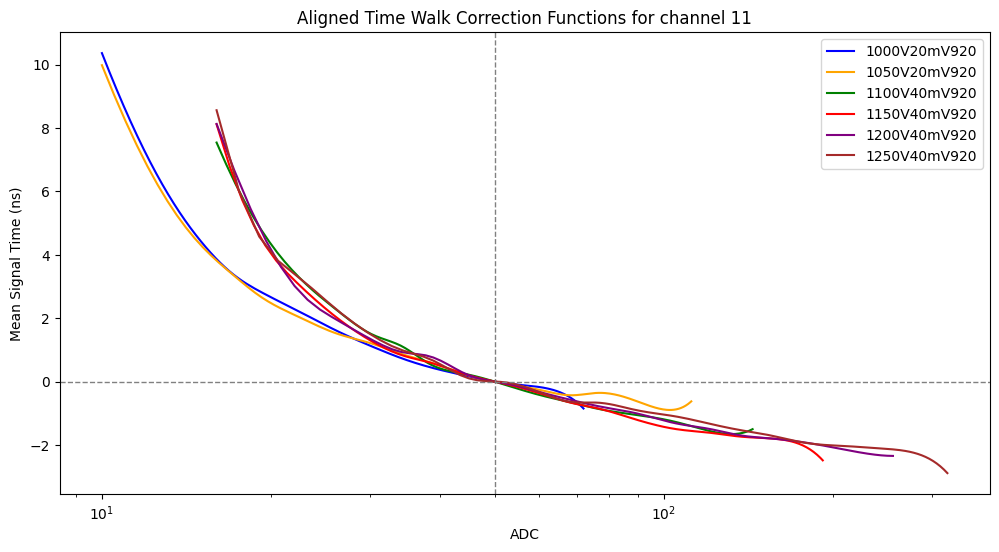

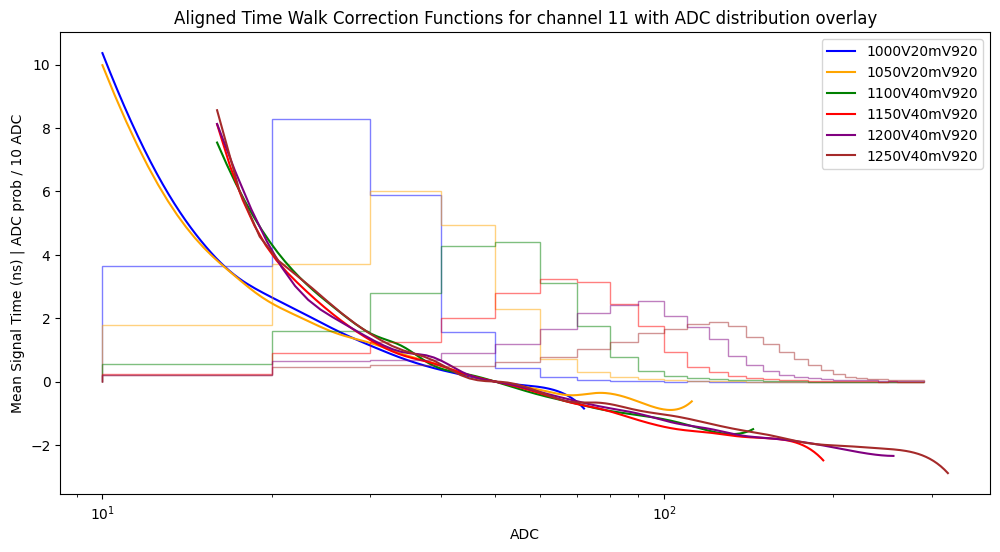

In [42]:
# Overlay the correction functions, use log x axis to better see the low ADC region

# find correction factors to align all at t=0 at ADC = 50
offsets = {}
for run_name in time_walk_correction_funcs.keys():
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    offset = time_walk_correction_func(50)
    offsets[run_name] = offset

# define six distinct colors for the different HV settings:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i in range(3):  # with and without offset applied and with adc distributions overlayed
    plt.figure(figsize=(12, 6))
    for ic,run_name in enumerate(time_walk_correction_funcs.keys()):
        time_walk_correction_func = time_walk_correction_funcs[run_name]
        fit_range = time_walk_correction_ranges[run_name]

        x_fit = np.linspace(fit_range[0], fit_range[1], 200)
        y_fit = time_walk_correction_func(x_fit)
        if i>0:
            y_fit = time_walk_correction_func(x_fit) - offsets[run_name]
        plt.plot(x_fit, y_fit, label=f'{run_name}',color=colors[ic])

        if i==2: # overlay the adc distribution
            data = get_data(run_name=run_name, channel=channel)
            mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
            mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs']<400))
            counts,bins = np.histogram(data['adcs'][mask_led]-adc_offset,bins=np.arange(10,300,10))
            total_counts = np.sum(counts)
            scaled_counts = 20*counts/total_counts

            plt.hist(bins[:-1], bins, weights=scaled_counts, histtype='step', color=colors[ic], alpha=0.5)

        plt.xlabel('ADC')
        plt.ylabel('Mean Signal Time (ns)')
        plt.xscale('log')

    plt.legend()
    if i==0:
        plt.title(f'Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}.png')
    elif i==1:
        # add horizontal line at 0 and vertical line at 50:
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.axvline(50, color='gray', linestyle='--', linewidth=1)
        plt.title(f'Aligned Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_aligned.png')
    else:
        # overlay the adc distributions for the different
        plt.ylabel('Mean Signal Time (ns) | ADC prob / 10 ADC')
        plt.title(f'Aligned Time Walk Correction Functions for channel {channel} with ADC distribution overlay')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_aligned_overlay.png')
    plt.show()



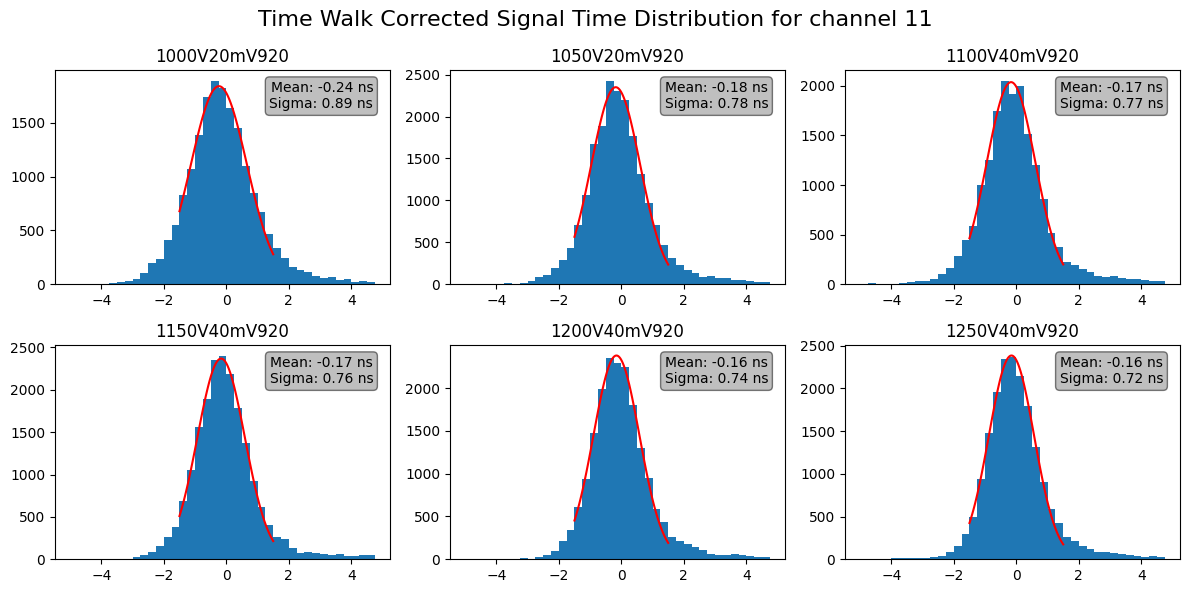

In [24]:
# Apply the time walk correction to the signal times, and show the distribution of signal times, use 2 rows and 3 columns

mean_cst = {}
std_cst = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6))
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

    corrected_signal_times = []
    for signal_time,adc in zip(data['signal_times'][mask_led],data['adcs'][mask_led]):
        time_walk = time_walk_correction_func(adc-adc_offset)
        corrected_signal_times.append(signal_time - time_walk)

    axis.hist(corrected_signal_times,bins=np.arange(-5.,5.,0.25))
    axis.set_title(f'{run_name}')

    # fit the range from -1.5 to 1.5 to a Gaussian

    hist, bin_edges = np.histogram(corrected_signal_times, bins=np.arange(-1.5,1.5,0.25))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Initial guess for fit parameters: amplitude, mean, stddev
    p0 = [np.max(hist), np.mean(corrected_signal_times), np.std(corrected_signal_times)]

    popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
    mean_cst[run_name] = popt[1]
    std_cst[run_name] = abs(popt[2])
    # Plot the fit
    x_fit = np.linspace(-1.5, 1.5, 100)
    y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
    axis.plot(x_fit, y_fit, color='red', linestyle='-')
    # Add a text box with mean and sigma values shown
    textstr = '\n'.join((
        f'Mean: {popt[1]:.2f} ns',
        f'Sigma: {abs(popt[2]):.2f} ns'))
    props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)


plt.suptitle(f'Time Walk Corrected Signal Time Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/corr_signal_time_distribution_chan{channel:02d}.png')
plt.show()


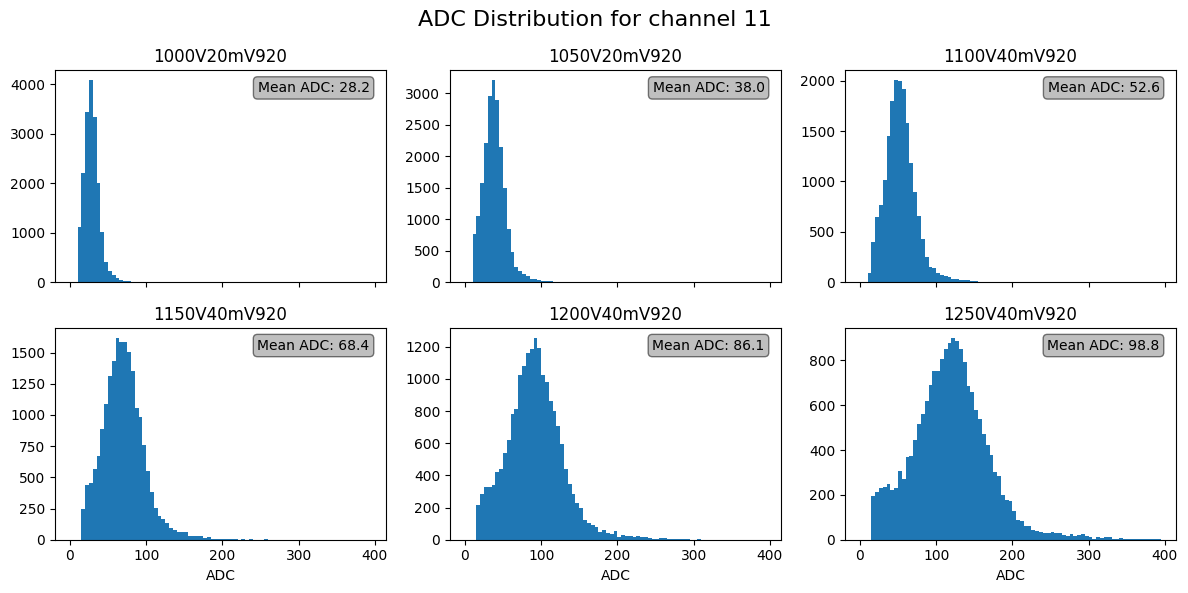

In [25]:
# Find the mean of the ADC distributions for the same runs to define the gains for each HV setting. Then plot the corrected signal time resolution (sigma from fit) as a function of gain.

mean_adcs = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6), sharex=True)
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
    mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs']<400))
    axis.hist(data['adcs'][mask_led]-adc_offset,bins=np.arange(0,400,5))
    axis.set_title(f'{run_name}')
    if i>2:
        axis.set_xlabel('ADC')

    mean_adc = np.mean(data['adcs'][mask_adc]) - adc_offset
    mean_adcs[run_name] = mean_adc

    # Add a text box with mean shown
    textstr = f'Mean ADC: {mean_adc:.1f}'
    props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)



plt.suptitle(f'ADC Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_distribution_chan{channel:02d}_led920.png')
plt.show()



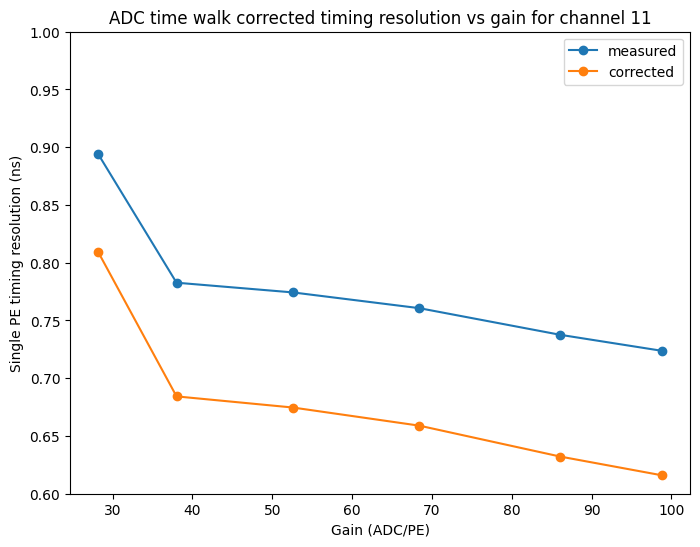

In [59]:
# Finally show the corrected signal time resolution as a function of mean ADC (gain proxy)

plt.figure(figsize=(8, 6))

gains = []
time_resols = []
corr_time_resols = []
for run_name in time_walk_correction_funcs.keys():
    gains.append(mean_adcs[run_name])
    time_resols.append(std_cst[run_name])
    corr_time_resols.append(np.sqrt(std_cst[run_name]**2-0.38**2))

plt.plot(gains, time_resols, marker='o', linestyle='-', label='measured')
plt.plot(gains, corr_time_resols, marker='o', linestyle='-', label='corrected')
plt.legend()
plt.xlabel('Gain (ADC/PE)')
plt.ylabel('Single PE timing resolution (ns)')
plt.title(f'ADC time walk corrected timing resolution vs gain for channel {channel}')
plt.ylim(0.6,1.)
plt.savefig(f'I:/fd2_analyses/adc_timing_resolution_chan{channel:02d}.png')
plt.show()
